# Plots of E vs r_c for 
i) different $\lambda$
ii) different Spin(a)

/tmp/ipykernel_93995/4206465773.py:84: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("viridis")


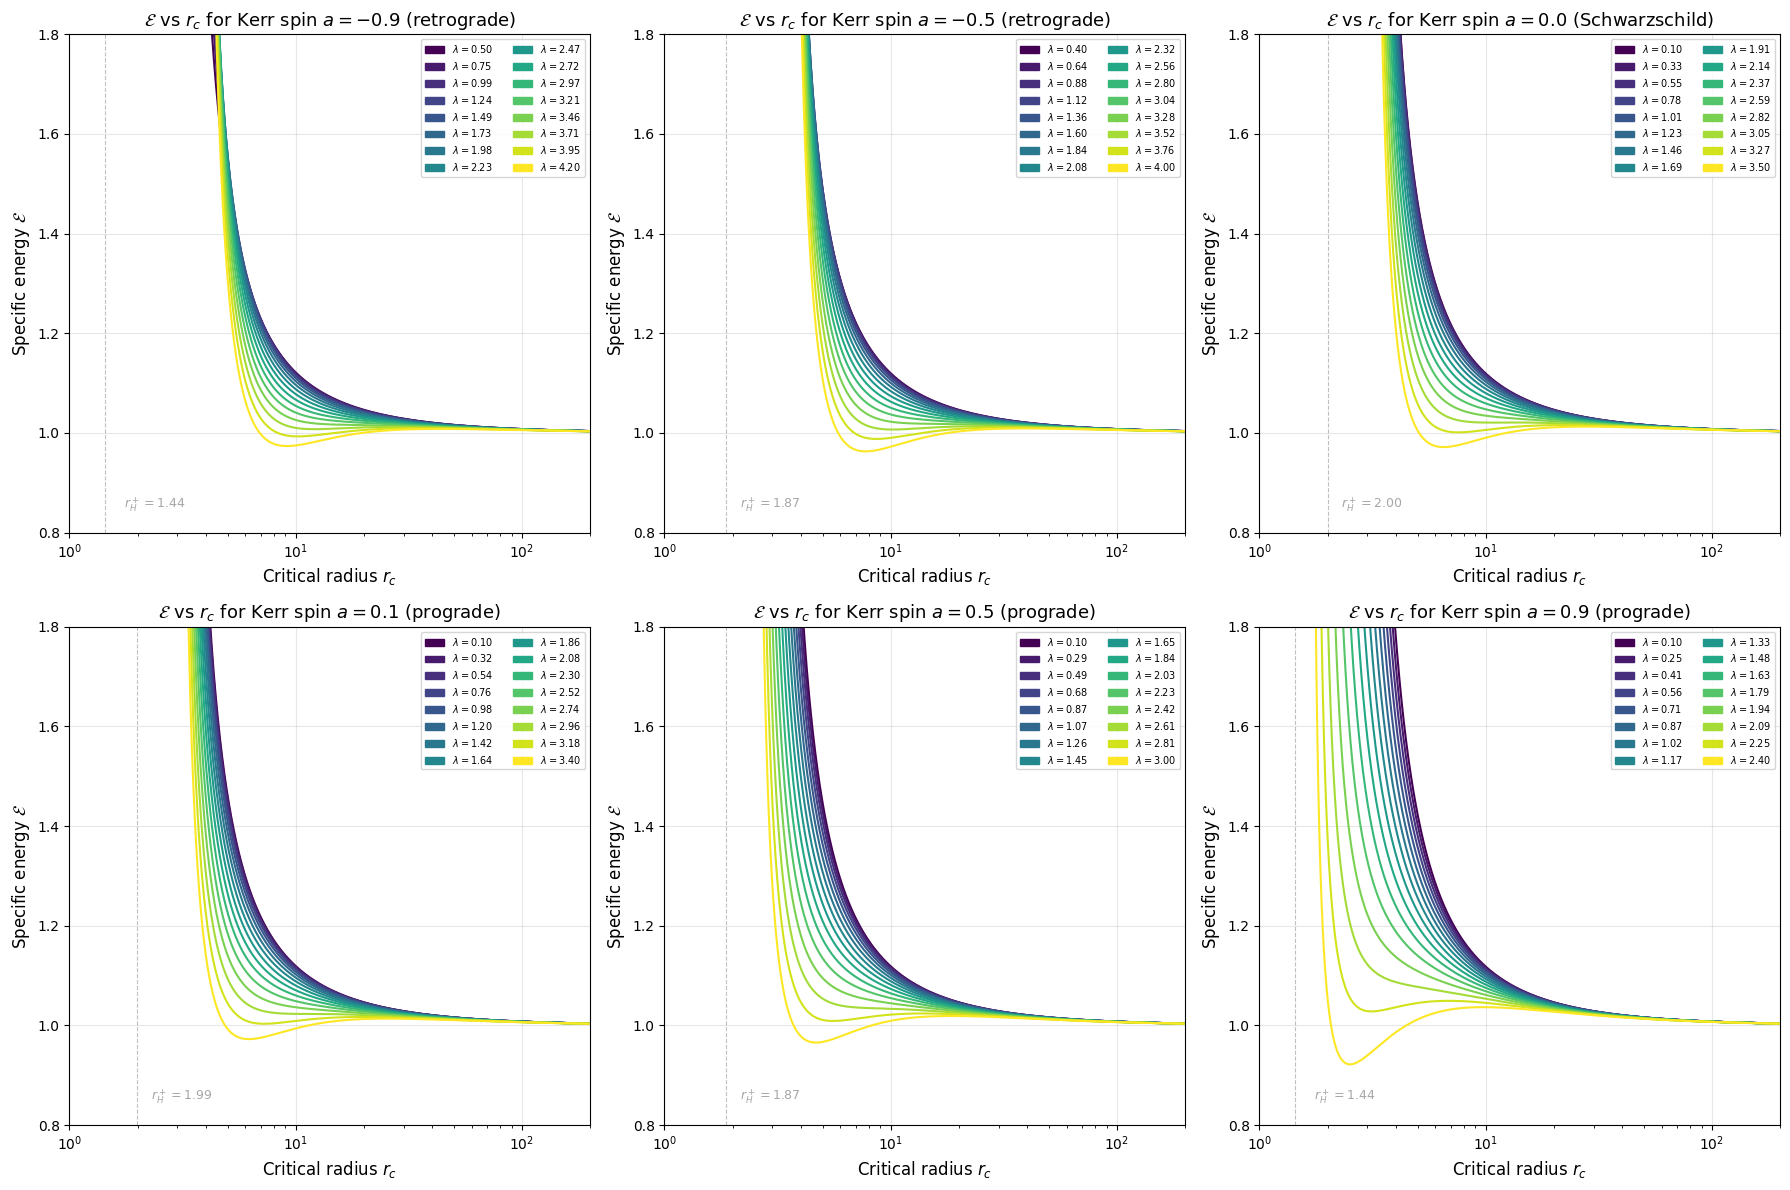

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.colors import Normalize
import matplotlib.patches as mpatches

# ================================================================
#  Specific energy at sonic radius r_c (provided by you)
# ================================================================
def Ec_computed_given_rc(r, lam, gamma, a):
    # Metric functions
    Delta = r**2 - 2*r + a**2
    A = r**4 + a**2*r**2 + 2*a**2*r

    # Derivatives
    Delta_prime = 2*r - 2
    A_prime = 4*r**3 + 2*a**2*r + 2*a**2

    # D term
    D = A**2 - 4*lam*a*r*A + lam**2 * r**2 * (4*a**2 - r**2 * Delta)
    if D == 0:
        return np.nan

    # D derivative
    D_prime = (
        2*A*A_prime
        - 4*lam*a*(A + r*A_prime)
        + lam**2 * (
            2*r*(4*a**2 - r**2*Delta)
            + r**2*(-2*r*Delta - r**2*Delta_prime)
        )
    )

    # Sonic functions
    S1 = 0.5 * (Delta_prime/Delta + 2.0/r)
    S2 = 0.5 * (Delta_prime/Delta + A_prime/A + 2.0/r - D_prime/D)

    # basic sonic checks
    if S1 * S2 <= 0:
        return np.nan

    cs2 = S2 / S1
    if cs2 <= 0 or cs2 >= 1:
        return np.nan

    cs = np.sqrt(cs2)
    u = cs

    factor = (gamma - 1.0) / (gamma - 1.0 - cs**2)
    if factor <= 0:
        return np.nan

    num = A * (r**2) * Delta
    denom = (1.0 - u**2) * (A**2 - 4.0*lam*a*r*A + lam**2 * r**2 * (4.0*a**2 - Delta*r**2))

    if num * denom <= 0:
        return np.nan

    E = factor * np.sqrt(num / denom)
    return E if np.isfinite(E) else np.nan


def plot_Ec_vs_rc_subplots_by_spin():
    gamma = 4.0 / 3.0

    # Kerr spins to be plotted
    a_values = [-0.9, -0.5, 0.0, 0.1, 0.5, 0.9]

    # λ ranges for each spin
    lambda_ranges = {
        -0.9: (0.5, 4.2),
        -0.5: (0.4, 4.0),
        0.0: (0.1, 3.5),
        0.1: (0.1, 3.4),
        0.5: (0.1, 3.0),
        0.9: (0.1, 2.4),
    }

    # Create 2x3 grid
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    # Better perceptual colormap
    cmap = get_cmap("viridis")

    for idx, a in enumerate(a_values):
        ax = axes[idx]

        # Calculate minimum radius for this spin: r_min = 1 + sqrt(1 - a^2)
        # (outer event horizon for Kerr black hole)
        r_horizon = 1 + np.sqrt(1 - a**2)
        r_start = r_horizon + 0.002  # Start just outside horizon

        lam_min, lam_max = lambda_ranges[a]
        lam_vals = np.linspace(lam_min, lam_max, 16)

        # Normalize λ for color mapping
        norm = Normalize(vmin=lam_min, vmax=lam_max)
        
        # Create custom legend handles with all colors
        legend_handles = []
        legend_labels = []

        # Generate radial sampling starting from r_start
        rc_vals = np.concatenate([
            np.linspace(r_start, r_start + 2.0, 1000),  # High res near horizon
            np.linspace(r_start + 2.0, 20.0, 8000),     # Medium resolution
            np.linspace(20.0, 100.0, 4000),             # Lower resolution
            np.linspace(100.0, 300.0, 2000)             # Very low resolution
        ])

        for lam in lam_vals:
            r_list, E_list = [], []

            for r in rc_vals:
                E = Ec_computed_given_rc(r, lam, gamma, a)
                
                # Check if E is valid (not NaN and numeric)
                if np.isfinite(E) and E > 0:
                    r_list.append(r)
                    E_list.append(E)

            if len(r_list) > 6:
                # Plot the curve
                color = cmap(norm(lam))
                ax.plot(
                    r_list, E_list,
                    lw=1.5,
                    color=color,
                )
                
                # Create a legend entry for this lambda value
                legend_handles.append(mpatches.Patch(color=color))
                legend_labels.append(rf"$\lambda={lam:.2f}$")

        ax.set_xlabel(r"Critical radius $r_c$", fontsize=12)
        ax.set_ylabel(r"Specific energy $\mathcal{E}$", fontsize=12)
        ax.set_xscale('log')
        # Set x-limits to start slightly before r_horizon for visual clarity
        ax.set_xlim(max(r_horizon - 1.0, 1.0), 200)
        ax.set_ylim(0.8, 1.8)

        # Add vertical line at the horizon for reference
        ax.axvline(x=r_horizon, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
        ax.text(r_horizon + 0.3, 0.85, rf'$r_H^+={r_horizon:.2f}$',
                fontsize=9, color='gray', alpha=0.7)

        if a < 0:
            sign = "retrograde"
        elif a > 0:
            sign = "prograde"
        else:
            sign = "Schwarzschild"

        ax.set_title(
            rf"$\mathcal{{E}}$ vs $r_c$ for Kerr spin $a={a}$ ({sign})",
            fontsize=13
        )

        ax.grid(alpha=0.3)

        # Add legend with ALL colors
        if legend_handles:
            # Use two columns for better layout
            ncol = 2
            ax.legend(handles=legend_handles, labels=legend_labels,
                     fontsize=7, ncol=ncol, loc='upper right',
                     framealpha=0.8, fancybox=True)

    # Remove only unused axes
    for j in range(len(a_values), len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig("Kerr_wedge_lambda.png", dpi=150, bbox_inches='tight')
    plt.show()


# Run the plotting function
plot_Ec_vs_rc_subplots_by_spin()

Horizon radii for each spin:
  a=-0.9: r_H^+ = 1.4359
  a=-0.5: r_H^+ = 1.8660
  a=0.0: r_H^+ = 2.0000
  a=0.1: r_H^+ = 1.9950
  a=0.5: r_H^+ = 1.8660
  a=0.9: r_H^+ = 1.4359

Processing λ=0.3...
  a=-0.9: Sampling from r=1.4369 to r=200 with 2800 points
    Valid points found: 1113
  a=-0.5: Sampling from r=1.8670 to r=200 with 2800 points
    Valid points found: 1101
  a=0.0: Sampling from r=2.0010 to r=200 with 2800 points
    Valid points found: 1106
  a=0.1: Sampling from r=1.9960 to r=200 with 2800 points
    Valid points found: 1109
  a=0.5: Sampling from r=1.8670 to r=200 with 2800 points
    Valid points found: 1134
  a=0.9: Sampling from r=1.4369 to r=200 with 2800 points
    Valid points found: 1178

Processing λ=0.7...
  a=-0.9: Sampling from r=1.4369 to r=200 with 2800 points
    Valid points found: 1082
  a=-0.5: Sampling from r=1.8670 to r=200 with 2800 points
    Valid points found: 1087
  a=0.0: Sampling from r=2.0010 to r=200 with 2800 points
    Valid points found: 1

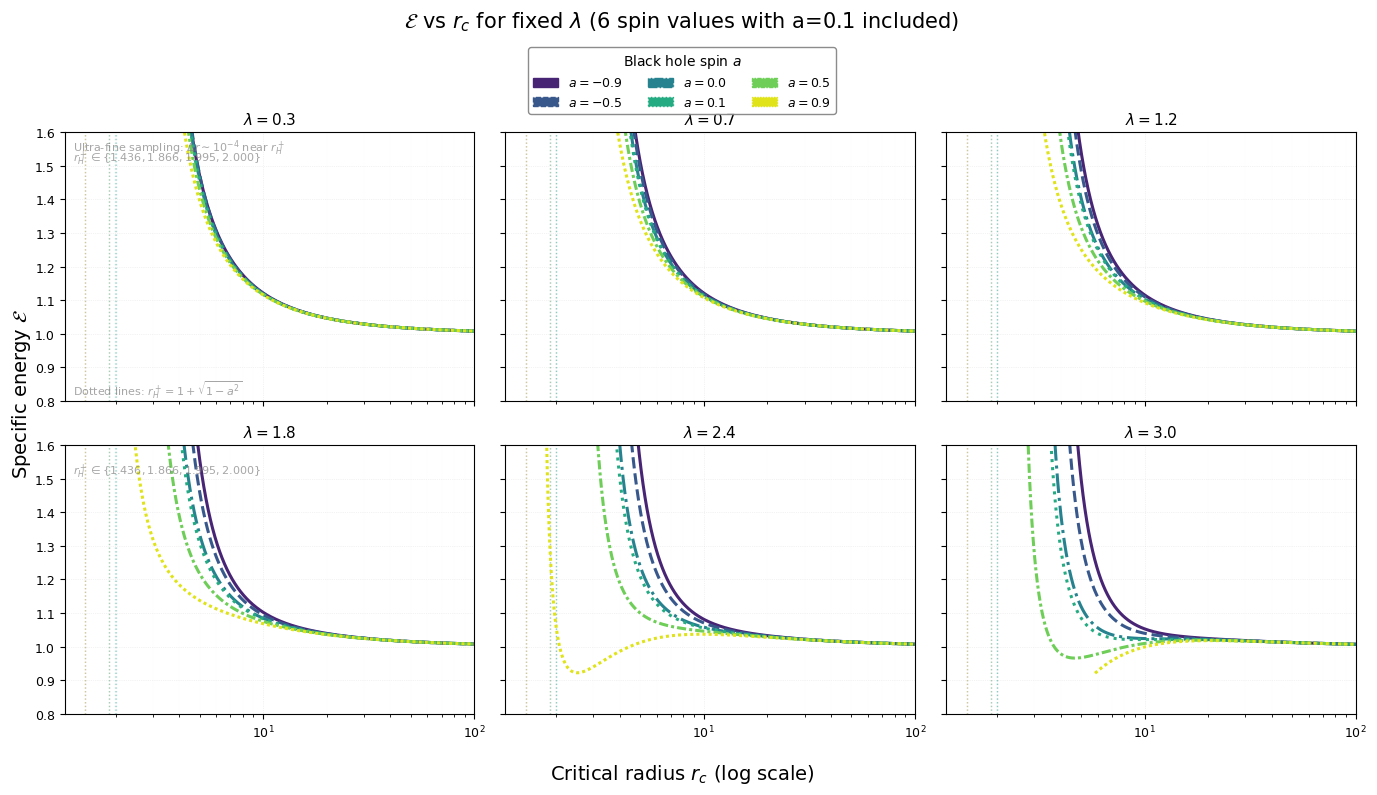

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ================================================================
#  Improved Specific energy at sonic radius r_c with better error handling
# ================================================================
def Ec_computed_given_rc(r, lam, gamma, a):
    try:
        # Metric functions
        Delta = r**2 - 2*r + a**2
        A = r**4 + a**2*r**2 + 2*a**2*r

        # Check for problematic values
        if Delta <= 1e-12 or A <= 1e-12:
            return np.nan

        # Derivatives
        Delta_prime = 2*r - 2
        A_prime = 4*r**3 + 2*a**2*r + 2*a**2

        # D term
        D = A**2 - 4*lam*a*r*A + lam**2 * r**2 * (4*a**2 - r**2 * Delta)
        if abs(D) < 1e-12:
            return np.nan

        # D derivative
        D_prime = (
            2*A*A_prime
            - 4*lam*a*(A + r*A_prime)
            + lam**2 * (
                2*r*(4*a**2 - r**2*Delta)
                + r**2*(-2*r*Delta - r**2*Delta_prime)
            )
        )

        # Sonic functions - handle near-zero cases
        S1 = 0.5 * (Delta_prime/Delta + 2.0/r)
        S2 = 0.5 * (Delta_prime/Delta + A_prime/A + 2.0/r - D_prime/D)

        # basic sonic checks
        if S1 * S2 <= 1e-12:
            return np.nan

        cs2 = S2 / S1
        if cs2 <= 1e-12 or cs2 >= 1 - 1e-12:
            return np.nan

        cs = np.sqrt(cs2)
        u = cs

        factor = (gamma - 1.0) / (gamma - 1.0 - cs**2)
        if factor <= 1e-12:
            return np.nan

        num = A * (r**2) * Delta
        denom = (1.0 - u**2) * (A**2 - 4.0*lam*a*r*A + lam**2 * r**2 * (4.0*a**2 - Delta*r**2))

        if num * denom <= 1e-12:
            return np.nan

        E = factor * np.sqrt(num / denom)
        return E if np.isfinite(E) else np.nan
    except Exception as e:
        return np.nan
    
def plot_Ec_vs_rc_subplots_by_lambda():
    gamma = 4.0 / 3.0
    a_values = [-0.9, -0.5, 0.0, 0.1, 0.5, 0.9]
    lam_vals = [0.3, 0.7, 1.2, 1.8, 2.4, 3.0]

    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True, sharey=True)
    axes = axes.flatten()

    colors = plt.cm.viridis(np.linspace(0.1, 0.95, len(a_values)))
    linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (1, 1))]
    
    # Store horizon radii for reference
    horizon_radii = {a: 1 + np.sqrt(1 - a**2) for a in a_values}
    print("Horizon radii for each spin:")
    for a in a_values:
        print(f"  a={a}: r_H^+ = {horizon_radii[a]:.4f}")

    for ax, lam in zip(axes, lam_vals):
        print(f"\nProcessing λ={lam}...")
        
        # Store legend handles for this subplot
        legend_handles = []
        legend_labels = []

        for a, c, ls in zip(a_values, colors, linestyles):
            # Calculate the horizon radius for this spin
            r_horizon = horizon_radii[a]
            r_start = r_horizon + 0.001  # Start VERY close to horizon
            
            # Create ULTRA-FINE radial sampling near horizon, then coarser
            # Below r=10: VERY high resolution
            # Above r=10: progressively coarser
            
            # Phase 1: Ultra-fine near horizon (r_horizon to r_horizon+0.1)
            rc_near_horizon = np.linspace(r_start, r_horizon + 0.1, 500)
            
            # Phase 2: Very fine from horizon+0.1 to 2.0
            rc_fine = np.linspace(r_horizon + 0.1, 2.0, 800)
            
            # Phase 3: Fine from 2.0 to 5.0
            rc_medium_fine = np.linspace(2.0, 5.0, 600)
            
            # Phase 4: Medium from 5.0 to 10.0
            rc_medium = np.linspace(5.0, 10.0, 400)
            
            # Phase 5: Coarser from 10.0 to 50.0
            rc_coarse = np.linspace(10.0, 50.0, 300)
            
            # Phase 6: Very coarse from 50.0 to 200.0
            rc_very_coarse = np.linspace(50.0, 200.0, 200)
            
            # Combine all radial arrays
            rc_vals = np.concatenate([
                rc_near_horizon, rc_fine, rc_medium_fine, 
                rc_medium, rc_coarse, rc_very_coarse
            ])
            
            # Sort to ensure monotonic increase
            rc_vals = np.sort(rc_vals)
            
            print(f"  a={a}: Sampling from r={r_start:.4f} to r=200 with {len(rc_vals)} points")
            
            r_list, E_list = [], []
            valid_points = 0
            
            # Track previous valid E to detect discontinuities
            prev_valid_E = None
            discontinuity_detected = False

            for r in rc_vals:
                try:
                    E = Ec_computed_given_rc(r, lam, gamma, a)

                    if np.isfinite(E) and 0.6 < E < 2.0:
                        r_list.append(r)
                        E_list.append(E)
                        valid_points += 1
                        
                        # Check for large jumps (discontinuities)
                        if prev_valid_E is not None:
                            delta_E = abs(E - prev_valid_E)
                            if delta_E > 0.5:  # Large jump detected
                                discontinuity_detected = True
                                # Start a new segment after discontinuity
                                if len(r_list) > 10:
                                    # Plot current segment
                                    ax.plot(
                                        r_list, E_list,
                                        lw=2.2,
                                        color=c,
                                        linestyle=ls,
                                        alpha=0.8 if discontinuity_detected else 1.0
                                    )
                                    # Reset for next segment
                                    r_list, E_list = [r], [E]
                        prev_valid_E = E
                    else:
                        # If we lose continuity, start a new segment
                        if len(r_list) > 10:
                            ax.plot(
                                r_list, E_list,
                                lw=2.2,
                                color=c,
                                linestyle=ls,
                                alpha=0.8 if discontinuity_detected else 1.0
                            )
                        r_list, E_list = [], []
                        prev_valid_E = None
                        
                except Exception as e:
                    # Skip points with calculation errors
                    if len(r_list) > 10:
                        ax.plot(
                            r_list, E_list,
                            lw=2.2,
                            color=c,
                            linestyle=ls,
                            alpha=0.8
                        )
                    r_list, E_list = [], []
                    prev_valid_E = None

            # Plot any remaining points
            if len(r_list) > 10:
                ax.plot(
                    r_list, E_list,
                    lw=2.2,
                    color=c,
                    linestyle=ls,
                )
                # Create legend entry (once per spin)
                if len(legend_handles) < len(a_values):
                    legend_handles.append(mpatches.Patch(color=c, linestyle=ls))
                    legend_labels.append(rf"$a={a}$")
            
            print(f"    Valid points found: {valid_points}")

        # Mark ALL horizon radii in EVERY plot with vertical lines
        for a, c, ls in zip(a_values, colors, linestyles):
            r_horizon = horizon_radii[a]
            ax.axvline(x=r_horizon, color=c, linestyle=':', 
                      alpha=0.3, linewidth=1.0, zorder=1)

        ax.set_title(rf"$\lambda={lam}$", fontsize=11)
        ax.grid(alpha=0.3, linestyle=':', linewidth=0.5)
        
        # Add secondary grid for better readability near horizon
        ax.grid(True, which='minor', alpha=0.1, linestyle=':', linewidth=0.3)

    # Set appropriate limits - LOG scale with careful range
    max_horizon = max(horizon_radii.values())
    min_horizon = min(horizon_radii.values())
    
    for ax in axes:
        ax.set_xscale("log")
        # Set x-limits: start from just below smallest horizon for visibility
        ax.set_xlim(min_horizon * 0.8, 100)
        ax.set_ylim(0.8, 1.6)
        
        # Add finer ticks on log scale
        ax.xaxis.set_major_locator(plt.LogLocator(base=10.0, numticks=10))
        ax.xaxis.set_minor_locator(plt.LogLocator(base=10.0, subs=np.arange(1, 10)*0.1, numticks=100))
        
        # Customize tick labels for better readability
        ax.tick_params(axis='x', which='both', labelsize=9)
        ax.tick_params(axis='y', which='both', labelsize=9)
        
        # Add minor grid
        ax.grid(True, which='minor', alpha=0.1, linestyle=':', linewidth=0.3)
        
        # Add a note about resolution
        if ax == axes[0]:
            ax.text(0.02, 0.98, r"Ultra-fine sampling: $\Delta r \sim 10^{-4}$ near $r_H^+$", 
                   transform=ax.transAxes, fontsize=8, color='gray', alpha=0.7,
                   verticalalignment='top')
            ax.text(0.02, 0.02, r"Dotted lines: $r_H^+ = 1+\sqrt{1-a^2}$", 
                   transform=ax.transAxes, fontsize=8, color='gray', alpha=0.7)
        
        # Add horizon annotations in the first plot of each row
        if ax in [axes[0], axes[3]]:
            # List unique horizon radii
            unique_horizons = sorted(set([round(h, 3) for h in horizon_radii.values()]))
            horizon_text = ", ".join([f"{h:.3f}" for h in unique_horizons])
            ax.text(0.02, 0.94, rf"$r_H^+ \in \{{{horizon_text}\}}$", 
                   transform=ax.transAxes, fontsize=8, color='gray', alpha=0.7,
                   verticalalignment='top')

    fig.supxlabel(r"Critical radius $r_c$ (log scale)", fontsize=14)
    fig.supylabel(r"Specific energy $\mathcal{E}$", fontsize=14)

    # One clean legend with all colors and linestyles
    fig.legend(legend_handles, legend_labels,
               loc="upper center",
               ncol=3,  # Changed to 3 columns for better layout with 6 spins
               frameon=True,
               framealpha=0.9,
               fancybox=True,
               edgecolor='gray',
               bbox_to_anchor=(0.5, 0.94),  # Adjusted slightly upward
               fontsize=9,  # Slightly smaller font
               title="Black hole spin $a$",
               title_fontsize=10)

    fig.suptitle(
        r"$\mathcal{E}$ vs $r_c$ for fixed $\lambda$ (6 spin values with a=0.1 included)",
        fontsize=15
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig("Kerr_wedge_a_ultrafine_with_0p1.png", dpi=200, bbox_inches='tight')
    plt.show()

plot_Ec_vs_rc_subplots_by_lambda()

# Plotting rc vs { E(a) - E(0) } for different spins(a)

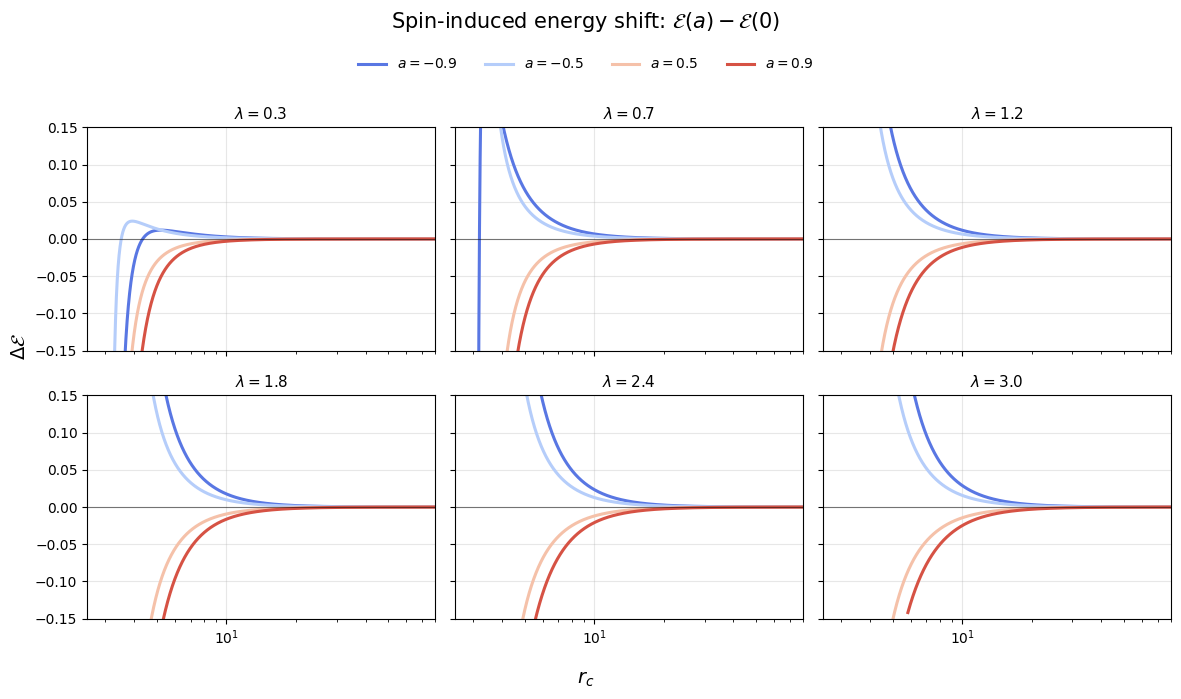

In [6]:
def plot_deltaE_vs_rc_subplots_by_lambda():

    gamma = 4.0 / 3.0
    a_values = [-0.9, -0.5, 0.5, 0.9]   # exclude a=0 (reference)
    lam_vals = [0.3, 0.7, 1.2, 1.8, 2.4, 3.0]

    rc_vals = np.logspace(np.log10(2.5), np.log10(80.0), 6000)

    fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
    axes = axes.flatten()

    colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(a_values)))

    for ax, lam in zip(axes, lam_vals):

        # Schwarzschild reference
        E0 = np.array([
            Ec_computed_given_rc(r, lam, gamma, 0.0)
            for r in rc_vals
        ])

        for a, c in zip(a_values, colors):

            dE = []
            r_plot = []

            for r, Eref in zip(rc_vals, E0):
                E = Ec_computed_given_rc(r, lam, gamma, a)

                if np.isfinite(E) and np.isfinite(Eref):
                    dE.append(E - Eref)
                    r_plot.append(r)

            ax.plot(r_plot, dE, lw=2.2, color=c, label=rf"$a={a}$")

        ax.axhline(0, color="k", lw=0.8, alpha=0.5)
        ax.set_title(rf"$\lambda={lam}$", fontsize=11)
        ax.grid(alpha=0.3)

    for ax in axes:
        ax.set_xscale("log")
        ax.set_xlim(2.5, 80)
        ax.set_ylim(-0.15, 0.15)

    fig.supxlabel(r"$r_c$", fontsize=14)
    fig.supylabel(r"$\Delta \mathcal{E}$", fontsize=14)

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(handles, labels,
           loc="upper center",
           ncol=4,
           frameon=False,
           bbox_to_anchor=(0.5, 0.93))


    fig.suptitle(
        r"Spin-induced energy shift: $\mathcal{E}(a)-\mathcal{E}(0)$",
        fontsize=15
    )

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.show()

plot_deltaE_vs_rc_subplots_by_lambda()

# Symbolic computation of du/dr at critical point using L-Hospital Rule

In [244]:
import sympy as sp

# -------------------------------------------------
# Symbols
# -------------------------------------------------
r = sp.Symbol('r')
gamma, lam, a = sp.symbols('gamma lam a', constant=True)
u, cs, v = sp.symbols('u cs v')

# -------------------------------------------------
# Metric functions
# -------------------------------------------------
Delta = r**2 - 2*r + a**2
A     = r**4 + a**2*r**2 + 2*a**2*r
D     = A**2 - 4*lam*a*r*A + lam**2 * r**2 * (4*a**2 - r**2 * Delta)

# -------------------------------------------------
# Derivatives w.r.t r
# -------------------------------------------------
Delta_r = sp.diff(Delta, r)
A_r     = sp.diff(A, r)
D_r     = sp.diff(D, r)

print("Delta_r :", Delta_r)
print("A_r:", A_r)
print("D_r:", D_r)


# -------------------------------------------------
# S1 and S2
# -------------------------------------------------
S1 = sp.Rational(1,2)*(Delta_r/Delta + 2/r)
S2 = sp.Rational(1,2)*(Delta_r/Delta + A_r/A + 2/r - D_r/D)

# -------------------------------------------------
# Derivatives of S1 and S2
# -------------------------------------------------
S1_r = sp.diff(S1, r)
S2_r = sp.diff(S2, r)
print("S1_r:", S1_r)
print("S2_r:", S2_r)
# -------------------------------------------------
# s = dc_s/dr  (same as your original definition)
# -------------------------------------------------
s = -sp.Rational(1,2)*cs*(gamma - 1 - cs**2)*(
        sp.Rational(1,2)*Delta_r/Delta + 1/r + v*(1/u + u/(1-u**2))
    )

# -------------------------------------------------
# Expression to be solved
# -------------------------------------------------
expr = (
    2*v**2
    - 2*v*s
    + (1 - u**2)*(S2_r - 2*cs*s*S1 - cs**2*S1_r)
)

expr = sp.expand(expr)

# -------------------------------------------------
# Collect as quadratic in v
# -------------------------------------------------
terms = sp.collect(expr, v, evaluate=False)

Aq = sp.simplify(terms.get(v**2, 0))
Bq = sp.simplify(terms.get(v, 0))
Cq = sp.simplify(terms.get(1, 0))

print("\nQuadratic coefficients:")
print("\nAq ="); print(Aq)
print("\nBq ="); print(Bq)
print("\nCq ="); print(Cq)


Delta_r : 2*r - 2
A_r: 2*a**2*r + 2*a**2 + 4*r**3
D_r: -4*a*lam*r*(2*a**2*r + 2*a**2 + 4*r**3) - 4*a*lam*(a**2*r**2 + 2*a**2*r + r**4) + lam**2*r**2*(-r**2*(2*r - 2) - 2*r*(a**2 + r**2 - 2*r)) + 2*lam**2*r*(4*a**2 - r**2*(a**2 + r**2 - 2*r)) + (4*a**2*r + 4*a**2 + 8*r**3)*(a**2*r**2 + 2*a**2*r + r**4)
S1_r: (2 - 2*r)*(2*r - 2)/(2*(a**2 + r**2 - 2*r)**2) + 1/(a**2 + r**2 - 2*r) - 1/r**2
S2_r: (2 - 2*r)*(2*r - 2)/(2*(a**2 + r**2 - 2*r)**2) + (2*a**2 + 12*r**2)/(2*(a**2*r**2 + 2*a**2*r + r**4)) + (-2*a**2*r - 2*a**2 - 4*r**3)*(2*a**2*r + 2*a**2 + 4*r**3)/(2*(a**2*r**2 + 2*a**2*r + r**4)**2) - (-4*a*lam*r*(2*a**2 + 12*r**2) - 8*a*lam*(2*a**2*r + 2*a**2 + 4*r**3) + lam**2*r**2*(-2*a**2 - 4*r**2 - 4*r*(2*r - 2) + 4*r) + 4*lam**2*r*(-r**2*(2*r - 2) - 2*r*(a**2 + r**2 - 2*r)) + 2*lam**2*(4*a**2 - r**2*(a**2 + r**2 - 2*r)) + (4*a**2 + 24*r**2)*(a**2*r**2 + 2*a**2*r + r**4) + (2*a**2*r + 2*a**2 + 4*r**3)*(4*a**2*r + 4*a**2 + 8*r**3))/(2*(-4*a*lam*r*(a**2*r**2 + 2*a**2*r + r**4) + lam**2*r**2*(4*

# Necessary functions like 
i) finding velocity gradient at sonic point 
ii) finding sound speed gradient at sonic point
iii) finding sound speed gradient for a regular point 
iv) finding velocity gradient for a regular point 
v) finding sonic point velocity
vi) finding metric functions and their gradients vii) RK4 step

In [2]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt


def find_vel_gradient_at_critical(u, cs, gamma, lam, a, r):

    u = cs
    Aq = (cs**3 - cs*gamma + cs + 2*u**3 - 2*u)/(u**3 - u)

    Bq = cs*(-a**2*cs**3 - a**2*cs**2*u + a**2*cs*gamma - a**2*cs + a**2*gamma*u - a**2*u - 2*cs**3*r**2 + 3*cs**3*r - 2*cs**2*r**2*u + 3*cs**2*r*u + 2*cs*gamma*r**2 - 3*cs*gamma*r - 2*cs*r**2 + 3*cs*r + 2*gamma*r**2*u - 3*gamma*r*u - 2*r**2*u + 3*r*u)/(r*u*(a**2 + r**2 - 2*r))

    Cq = (a**8*cs**4*r**2*u**2 - a**8*cs**4*r**2 + 4*a**8*cs**4*r*u**2 - 4*a**8*cs**4*r + 4*a**8*cs**4*u**2 - 4*a**8*cs**4 - a**8*cs**2*gamma*r**2*u**2 + a**8*cs**2*gamma*r**2 - 4*a**8*cs**2*gamma*r*u**2 + 4*a**8*cs**2*gamma*r - 4*a**8*cs**2*gamma*u**2 + 4*a**8*cs**2*gamma + 2*a**8*r*u**2 - 2*a**8*r + 2*a**8*u**2 - 2*a**8 - 8*a**7*cs**4*lam*r*u**2 + 8*a**7*cs**4*lam*r - 16*a**7*cs**4*lam*u**2 + 16*a**7*cs**4*lam + 8*a**7*cs**2*gamma*lam*r*u**2 - 8*a**7*cs**2*gamma*lam*r + 16*a**7*cs**2*gamma*lam*u**2 - 16*a**7*cs**2*gamma*lam - 4*a**7*lam*r*u**2 + 4*a**7*lam*r - 8*a**7*lam*u**2 + 8*a**7*lam - 2*a**6*cs**4*lam**2*r**2*u**2 + 2*a**6*cs**4*lam**2*r**2 + 24*a**6*cs**4*lam**2*u**2 - 24*a**6*cs**4*lam**2 + 6*a**6*cs**4*r**4*u**2 - 6*a**6*cs**4*r**4 + 14*a**6*cs**4*r**3*u**2 - 14*a**6*cs**4*r**3 - 8*a**6*cs**4*r**2*u**2 + 8*a**6*cs**4*r**2 - 24*a**6*cs**4*r*u**2 + 24*a**6*cs**4*r + 2*a**6*cs**2*gamma*lam**2*r**2*u**2 - 2*a**6*cs**2*gamma*lam**2*r**2 - 24*a**6*cs**2*gamma*lam**2*u**2 + 24*a**6*cs**2*gamma*lam**2 - 6*a**6*cs**2*gamma*r**4*u**2 + 6*a**6*cs**2*gamma*r**4 - 14*a**6*cs**2*gamma*r**3*u**2 + 14*a**6*cs**2*gamma*r**3 + 8*a**6*cs**2*gamma*r**2*u**2 - 8*a**6*cs**2*gamma*r**2 + 24*a**6*cs**2*gamma*r*u**2 - 24*a**6*cs**2*gamma*r + 3*a**6*cs**2*r**4*u**2 - 3*a**6*cs**2*r**4 + 10*a**6*cs**2*r**3*u**2 - 10*a**6*cs**2*r**3 + 4*a**6*cs**2*r**2*u**2 - 4*a**6*cs**2*r**2 - 8*a**6*cs**2*r*u**2 + 8*a**6*cs**2*r + 12*a**6*lam**2*u**2 - 12*a**6*lam**2 + 8*a**6*r**3*u**2 - 8*a**6*r**3 - 8*a**6*r**2*u**2 + 8*a**6*r**2 - 8*a**6*r*u**2 + 8*a**6*r + 8*a**5*cs**4*lam**3*r*u**2 - 8*a**5*cs**4*lam**3*r - 16*a**5*cs**4*lam**3*u**2 + 16*a**5*cs**4*lam**3 - 40*a**5*cs**4*lam*r**3*u**2 + 40*a**5*cs**4*lam*r**3 - 16*a**5*cs**4*lam*r**2*u**2 + 16*a**5*cs**4*lam*r**2 + 96*a**5*cs**4*lam*r*u**2 - 96*a**5*cs**4*lam*r - 8*a**5*cs**2*gamma*lam**3*r*u**2 + 8*a**5*cs**2*gamma*lam**3*r + 16*a**5*cs**2*gamma*lam**3*u**2 - 16*a**5*cs**2*gamma*lam**3 + 40*a**5*cs**2*gamma*lam*r**3*u**2 - 40*a**5*cs**2*gamma*lam*r**3 + 16*a**5*cs**2*gamma*lam*r**2*u**2 - 16*a**5*cs**2*gamma*lam*r**2 - 96*a**5*cs**2*gamma*lam*r*u**2 + 96*a**5*cs**2*gamma*lam*r - 24*a**5*cs**2*lam*r**3*u**2 + 24*a**5*cs**2*lam*r**3 - 32*a**5*cs**2*lam*r**2*u**2 + 32*a**5*cs**2*lam*r**2 + 32*a**5*cs**2*lam*r*u**2 - 32*a**5*cs**2*lam*r + 4*a**5*lam**3*r*u**2 - 4*a**5*lam**3*r - 8*a**5*lam**3*u**2 + 8*a**5*lam**3 - 16*a**5*lam*r**3*u**2 + 16*a**5*lam*r**3 + 16*a**5*lam*r**2*u**2 - 16*a**5*lam*r**2 + 32*a**5*lam*r*u**2 - 32*a**5*lam*r + a**4*cs**4*lam**4*r**2*u**2 - a**4*cs**4*lam**4*r**2 - 4*a**4*cs**4*lam**4*r*u**2 + 4*a**4*cs**4*lam**4*r + 4*a**4*cs**4*lam**4*u**2 - 4*a**4*cs**4*lam**4 - 10*a**4*cs**4*lam**2*r**4*u**2 + 10*a**4*cs**4*lam**2*r**4 + 16*a**4*cs**4*lam**2*r**3*u**2 - 16*a**4*cs**4*lam**2*r**3 + 96*a**4*cs**4*lam**2*r**2*u**2 - 96*a**4*cs**4*lam**2*r**2 - 144*a**4*cs**4*lam**2*r*u**2 + 144*a**4*cs**4*lam**2*r + 13*a**4*cs**4*r**6*u**2 - 13*a**4*cs**4*r**6 + 8*a**4*cs**4*r**5*u**2 - 8*a**4*cs**4*r**5 - 47*a**4*cs**4*r**4*u**2 + 47*a**4*cs**4*r**4 - 12*a**4*cs**4*r**3*u**2 + 12*a**4*cs**4*r**3 + 36*a**4*cs**4*r**2*u**2 - 36*a**4*cs**4*r**2 - a**4*cs**2*gamma*lam**4*r**2*u**2 + a**4*cs**2*gamma*lam**4*r**2 + 4*a**4*cs**2*gamma*lam**4*r*u**2 - 4*a**4*cs**2*gamma*lam**4*r - 4*a**4*cs**2*gamma*lam**4*u**2 + 4*a**4*cs**2*gamma*lam**4 + 10*a**4*cs**2*gamma*lam**2*r**4*u**2 - 10*a**4*cs**2*gamma*lam**2*r**4 - 16*a**4*cs**2*gamma*lam**2*r**3*u**2 + 16*a**4*cs**2*gamma*lam**2*r**3 - 96*a**4*cs**2*gamma*lam**2*r**2*u**2 + 96*a**4*cs**2*gamma*lam**2*r**2 + 144*a**4*cs**2*gamma*lam**2*r*u**2 - 144*a**4*cs**2*gamma*lam**2*r - 13*a**4*cs**2*gamma*r**6*u**2 + 13*a**4*cs**2*gamma*r**6 - 8*a**4*cs**2*gamma*r**5*u**2 + 8*a**4*cs**2*gamma*r**5 + 47*a**4*cs**2*gamma*r**4*u**2 - 47*a**4*cs**2*gamma*r**4 + 12*a**4*cs**2*gamma*r**3*u**2 - 12*a**4*cs**2*gamma*r**3 - 36*a**4*cs**2*gamma*r**2*u**2 + 36*a**4*cs**2*gamma*r**2 - 6*a**4*cs**2*lam**2*r**4*u**2 + 6*a**4*cs**2*lam**2*r**4 + 4*a**4*cs**2*lam**2*r**3*u**2 - 4*a**4*cs**2*lam**2*r**3 + 72*a**4*cs**2*lam**2*r**2*u**2 - 72*a**4*cs**2*lam**2*r**2 - 48*a**4*cs**2*lam**2*r*u**2 + 48*a**4*cs**2*lam**2*r + 8*a**4*cs**2*r**6*u**2 - 8*a**4*cs**2*r**6 + 10*a**4*cs**2*r**5*u**2 - 10*a**4*cs**2*r**5 - 21*a**4*cs**2*r**4*u**2 + 21*a**4*cs**2*r**4 - 12*a**4*cs**2*r**3*u**2 + 12*a**4*cs**2*r**3 + 12*a**4*cs**2*r**2*u**2 - 12*a**4*cs**2*r**2 - 2*a**4*lam**4*r*u**2 + 2*a**4*lam**4*r + 2*a**4*lam**4*u**2 - 2*a**4*lam**4 + a**4*lam**2*r**4*u**2 - a**4*lam**2*r**4 + 8*a**4*lam**2*r**3*u**2 - 8*a**4*lam**2*r**3 - 48*a**4*lam**2*r*u**2 + 48*a**4*lam**2*r + 12*a**4*r**5*u**2 - 12*a**4*r**5 - 40*a**4*r**4*u**2 + 40*a**4*r**4 + 16*a**4*r**2*u**2 - 16*a**4*r**2 + 32*a**3*cs**4*lam**3*r**3*u**2 - 32*a**3*cs**4*lam**3*r**3 - 112*a**3*cs**4*lam**3*r**2*u**2 + 112*a**3*cs**4*lam**3*r**2 + 96*a**3*cs**4*lam**3*r*u**2 - 96*a**3*cs**4*lam**3*r - 64*a**3*cs**4*lam*r**5*u**2 + 64*a**3*cs**4*lam*r**5 + 80*a**3*cs**4*lam*r**4*u**2 - 80*a**3*cs**4*lam*r**4 + 120*a**3*cs**4*lam*r**3*u**2 - 120*a**3*cs**4*lam*r**3 - 144*a**3*cs**4*lam*r**2*u**2 + 144*a**3*cs**4*lam*r**2 - 32*a**3*cs**2*gamma*lam**3*r**3*u**2 + 32*a**3*cs**2*gamma*lam**3*r**3 + 112*a**3*cs**2*gamma*lam**3*r**2*u**2 - 112*a**3*cs**2*gamma*lam**3*r**2 - 96*a**3*cs**2*gamma*lam**3*r*u**2 + 96*a**3*cs**2*gamma*lam**3*r + 64*a**3*cs**2*gamma*lam*r**5*u**2 - 64*a**3*cs**2*gamma*lam*r**5 - 80*a**3*cs**2*gamma*lam*r**4*u**2 + 80*a**3*cs**2*gamma*lam*r**4 - 120*a**3*cs**2*gamma*lam*r**3*u**2 + 120*a**3*cs**2*gamma*lam*r**3 + 144*a**3*cs**2*gamma*lam*r**2*u**2 - 144*a**3*cs**2*gamma*lam*r**2 + 24*a**3*cs**2*lam**3*r**3*u**2 - 24*a**3*cs**2*lam**3*r**3 - 64*a**3*cs**2*lam**3*r**2*u**2 + 64*a**3*cs**2*lam**3*r**2 + 32*a**3*cs**2*lam**3*r*u**2 - 32*a**3*cs**2*lam**3*r - 40*a**3*cs**2*lam*r**5*u**2 + 40*a**3*cs**2*lam*r**5 + 32*a**3*cs**2*lam*r**4*u**2 - 32*a**3*cs**2*lam*r**4 + 72*a**3*cs**2*lam*r**3*u**2 - 72*a**3*cs**2*lam*r**3 - 48*a**3*cs**2*lam*r**2*u**2 + 48*a**3*cs**2*lam*r**2 - 16*a**3*lam**3*r**2*u**2 + 16*a**3*lam**3*r**2 + 32*a**3*lam**3*r*u**2 - 32*a**3*lam**3*r - 36*a**3*lam*r**5*u**2 + 36*a**3*lam*r**5 + 72*a**3*lam*r**4*u**2 - 72*a**3*lam*r**4 + 32*a**3*lam*r**3*u**2 - 32*a**3*lam*r**3 - 64*a**3*lam*r**2*u**2 + 64*a**3*lam*r**2 + 4*a**2*cs**4*lam**4*r**4*u**2 - 4*a**2*cs**4*lam**4*r**4 - 22*a**2*cs**4*lam**4*r**3*u**2 + 22*a**2*cs**4*lam**4*r**3 + 40*a**2*cs**4*lam**4*r**2*u**2 - 40*a**2*cs**4*lam**4*r**2 - 24*a**2*cs**4*lam**4*r*u**2 + 24*a**2*cs**4*lam**4*r - 16*a**2*cs**4*lam**2*r**6*u**2 + 16*a**2*cs**4*lam**2*r**6 + 52*a**2*cs**4*lam**2*r**5*u**2 - 52*a**2*cs**4*lam**2*r**5 + 54*a**2*cs**4*lam**2*r**4*u**2 - 54*a**2*cs**4*lam**2*r**4 - 288*a**2*cs**4*lam**2*r**3*u**2 + 288*a**2*cs**4*lam**2*r**3 + 216*a**2*cs**4*lam**2*r**2*u**2 - 216*a**2*cs**4*lam**2*r**2 + 12*a**2*cs**4*r**8*u**2 - 12*a**2*cs**4*r**8 - 14*a**2*cs**4*r**7*u**2 + 14*a**2*cs**4*r**7 - 30*a**2*cs**4*r**6*u**2 + 30*a**2*cs**4*r**6 + 36*a**2*cs**4*r**5*u**2 - 36*a**2*cs**4*r**5 - 4*a**2*cs**2*gamma*lam**4*r**4*u**2 + 4*a**2*cs**2*gamma*lam**4*r**4 + 22*a**2*cs**2*gamma*lam**4*r**3*u**2 - 22*a**2*cs**2*gamma*lam**4*r**3 - 40*a**2*cs**2*gamma*lam**4*r**2*u**2 + 40*a**2*cs**2*gamma*lam**4*r**2 + 24*a**2*cs**2*gamma*lam**4*r*u**2 - 24*a**2*cs**2*gamma*lam**4*r + 16*a**2*cs**2*gamma*lam**2*r**6*u**2 - 16*a**2*cs**2*gamma*lam**2*r**6 - 52*a**2*cs**2*gamma*lam**2*r**5*u**2 + 52*a**2*cs**2*gamma*lam**2*r**5 - 54*a**2*cs**2*gamma*lam**2*r**4*u**2 + 54*a**2*cs**2*gamma*lam**2*r**4 + 288*a**2*cs**2*gamma*lam**2*r**3*u**2 - 288*a**2*cs**2*gamma*lam**2*r**3 - 216*a**2*cs**2*gamma*lam**2*r**2*u**2 + 216*a**2*cs**2*gamma*lam**2*r**2 - 12*a**2*cs**2*gamma*r**8*u**2 + 12*a**2*cs**2*gamma*r**8 + 14*a**2*cs**2*gamma*r**7*u**2 - 14*a**2*cs**2*gamma*r**7 + 30*a**2*cs**2*gamma*r**6*u**2 - 30*a**2*cs**2*gamma*r**6 - 36*a**2*cs**2*gamma*r**5*u**2 + 36*a**2*cs**2*gamma*r**5 + 3*a**2*cs**2*lam**4*r**4*u**2 - 3*a**2*cs**2*lam**4*r**4 - 14*a**2*cs**2*lam**4*r**3*u**2 + 14*a**2*cs**2*lam**4*r**3 + 20*a**2*cs**2*lam**4*r**2*u**2 - 20*a**2*cs**2*lam**4*r**2 - 8*a**2*cs**2*lam**4*r*u**2 + 8*a**2*cs**2*lam**4*r - 10*a**2*cs**2*lam**2*r**6*u**2 + 10*a**2*cs**2*lam**2*r**6 + 28*a**2*cs**2*lam**2*r**5*u**2 - 28*a**2*cs**2*lam**2*r**5 + 34*a**2*cs**2*lam**2*r**4*u**2 - 34*a**2*cs**2*lam**2*r**4 - 144*a**2*cs**2*lam**2*r**3*u**2 + 144*a**2*cs**2*lam**2*r**3 + 72*a**2*cs**2*lam**2*r**2*u**2 - 72*a**2*cs**2*lam**2*r**2 + 7*a**2*cs**2*r**8*u**2 - 7*a**2*cs**2*r**8 - 6*a**2*cs**2*r**7*u**2 + 6*a**2*cs**2*r**7 - 18*a**2*cs**2*r**6*u**2 + 18*a**2*cs**2*r**6 + 12*a**2*cs**2*r**5*u**2 - 12*a**2*cs**2*r**5 - a**2*lam**4*r**4*u**2 + a**2*lam**4*r**4 + 8*a**2*lam**4*r**2*u**2 - 8*a**2*lam**4*r**2 - 8*a**2*lam**4*r*u**2 + 8*a**2*lam**4*r - 2*a**2*lam**2*r**6*u**2 + 2*a**2*lam**2*r**6 + 20*a**2*lam**2*r**5*u**2 - 20*a**2*lam**2*r**5 - 96*a**2*lam**2*r**3*u**2 + 96*a**2*lam**2*r**3 + 96*a**2*lam**2*r**2*u**2 - 96*a**2*lam**2*r**2 + 8*a**2*r**7*u**2 - 8*a**2*r**7 - 32*a**2*r**6*u**2 + 32*a**2*r**6 + 40*a**2*r**5*u**2 - 40*a**2*r**5 + 32*a*cs**4*lam**3*r**5*u**2 - 32*a*cs**4*lam**3*r**5 - 160*a*cs**4*lam**3*r**4*u**2 + 160*a*cs**4*lam**3*r**4 + 264*a*cs**4*lam**3*r**3*u**2 - 264*a*cs**4*lam**3*r**3 - 144*a*cs**4*lam**3*r**2*u**2 + 144*a*cs**4*lam**3*r**2 - 32*a*cs**4*lam*r**7*u**2 + 32*a*cs**4*lam*r**7 + 96*a*cs**4*lam*r**6*u**2 - 96*a*cs**4*lam*r**6 - 72*a*cs**4*lam*r**5*u**2 + 72*a*cs**4*lam*r**5 - 32*a*cs**2*gamma*lam**3*r**5*u**2 + 32*a*cs**2*gamma*lam**3*r**5 + 160*a*cs**2*gamma*lam**3*r**4*u**2 - 160*a*cs**2*gamma*lam**3*r**4 - 264*a*cs**2*gamma*lam**3*r**3*u**2 + 264*a*cs**2*gamma*lam**3*r**3 + 144*a*cs**2*gamma*lam**3*r**2*u**2 - 144*a*cs**2*gamma*lam**3*r**2 + 32*a*cs**2*gamma*lam*r**7*u**2 - 32*a*cs**2*gamma*lam*r**7 - 96*a*cs**2*gamma*lam*r**6*u**2 + 96*a*cs**2*gamma*lam*r**6 + 72*a*cs**2*gamma*lam*r**5*u**2 - 72*a*cs**2*gamma*lam*r**5 + 16*a*cs**2*lam**3*r**5*u**2 - 16*a*cs**2*lam**3*r**5 - 80*a*cs**2*lam**3*r**4*u**2 + 80*a*cs**2*lam**3*r**4 + 120*a*cs**2*lam**3*r**3*u**2 - 120*a*cs**2*lam**3*r**3 - 48*a*cs**2*lam**3*r**2*u**2 + 48*a*cs**2*lam**3*r**2 - 16*a*cs**2*lam*r**7*u**2 + 16*a*cs**2*lam*r**7 + 48*a*cs**2*lam*r**6*u**2 - 48*a*cs**2*lam*r**6 - 24*a*cs**2*lam*r**5*u**2 + 24*a*cs**2*lam*r**5 + 12*a*lam**3*r**5*u**2 - 12*a*lam**3*r**5 - 56*a*lam**3*r**4*u**2 + 56*a*lam**3*r**4 + 96*a*lam**3*r**3*u**2 - 96*a*lam**3*r**3 - 64*a*lam**3*r**2*u**2 + 64*a*lam**3*r**2 - 24*a*lam*r**7*u**2 + 24*a*lam*r**7 + 80*a*lam*r**6*u**2 - 80*a*lam*r**6 - 80*a*lam*r**5*u**2 + 80*a*lam*r**5 + 4*cs**4*lam**4*r**6*u**2 - 4*cs**4*lam**4*r**6 - 28*cs**4*lam**4*r**5*u**2 + 28*cs**4*lam**4*r**5 + 73*cs**4*lam**4*r**4*u**2 - 73*cs**4*lam**4*r**4 - 84*cs**4*lam**4*r**3*u**2 + 84*cs**4*lam**4*r**3 + 36*cs**4*lam**4*r**2*u**2 - 36*cs**4*lam**4*r**2 - 8*cs**4*lam**2*r**8*u**2 + 8*cs**4*lam**2*r**8 + 40*cs**4*lam**2*r**7*u**2 - 40*cs**4*lam**2*r**7 - 66*cs**4*lam**2*r**6*u**2 + 66*cs**4*lam**2*r**6 + 36*cs**4*lam**2*r**5*u**2 - 36*cs**4*lam**2*r**5 + 4*cs**4*r**10*u**2 - 4*cs**4*r**10 - 12*cs**4*r**9*u**2 + 12*cs**4*r**9 + 9*cs**4*r**8*u**2 - 9*cs**4*r**8 - 4*cs**2*gamma*lam**4*r**6*u**2 + 4*cs**2*gamma*lam**4*r**6 + 28*cs**2*gamma*lam**4*r**5*u**2 - 28*cs**2*gamma*lam**4*r**5 - 73*cs**2*gamma*lam**4*r**4*u**2 + 73*cs**2*gamma*lam**4*r**4 + 84*cs**2*gamma*lam**4*r**3*u**2 - 84*cs**2*gamma*lam**4*r**3 - 36*cs**2*gamma*lam**4*r**2*u**2 + 36*cs**2*gamma*lam**4*r**2 + 8*cs**2*gamma*lam**2*r**8*u**2 - 8*cs**2*gamma*lam**2*r**8 - 40*cs**2*gamma*lam**2*r**7*u**2 + 40*cs**2*gamma*lam**2*r**7 + 66*cs**2*gamma*lam**2*r**6*u**2 - 66*cs**2*gamma*lam**2*r**6 - 36*cs**2*gamma*lam**2*r**5*u**2 + 36*cs**2*gamma*lam**2*r**5 - 4*cs**2*gamma*r**10*u**2 + 4*cs**2*gamma*r**10 + 12*cs**2*gamma*r**9*u**2 - 12*cs**2*gamma*r**9 - 9*cs**2*gamma*r**8*u**2 + 9*cs**2*gamma*r**8 + 2*cs**2*lam**4*r**6*u**2 - 2*cs**2*lam**4*r**6 - 14*cs**2*lam**4*r**5*u**2 + 14*cs**2*lam**4*r**5 + 35*cs**2*lam**4*r**4*u**2 - 35*cs**2*lam**4*r**4 - 36*cs**2*lam**4*r**3*u**2 + 36*cs**2*lam**4*r**3 + 12*cs**2*lam**4*r**2*u**2 - 12*cs**2*lam**4*r**2 - 4*cs**2*lam**2*r**8*u**2 + 4*cs**2*lam**2*r**8 + 20*cs**2*lam**2*r**7*u**2 - 20*cs**2*lam**2*r**7 - 30*cs**2*lam**2*r**6*u**2 + 30*cs**2*lam**2*r**6 + 12*cs**2*lam**2*r**5*u**2 - 12*cs**2*lam**2*r**5 + 2*cs**2*r**10*u**2 - 2*cs**2*r**10 - 6*cs**2*r**9*u**2 + 6*cs**2*r**9 + 3*cs**2*r**8*u**2 - 3*cs**2*r**8 + lam**4*r**6*u**2 - lam**4*r**6 - 8*lam**4*r**5*u**2 + 8*lam**4*r**5 + 24*lam**4*r**4*u**2 - 24*lam**4*r**4 - 32*lam**4*r**3*u**2 + 32*lam**4*r**3 + 16*lam**4*r**2*u**2 - 16*lam**4*r**2 - 3*lam**2*r**8*u**2 + 3*lam**2*r**8 + 20*lam**2*r**7*u**2 - 20*lam**2*r**7 - 48*lam**2*r**6*u**2 + 48*lam**2*r**6 + 40*lam**2*r**5*u**2 - 40*lam**2*r**5 + 2*r**9*u**2 - 2*r**9 - 2*r**8*u**2 + 2*r**8)/(r**2*(a**8*r**2 + 4*a**8*r + 4*a**8 - 8*a**7*lam*r - 16*a**7*lam - 2*a**6*lam**2*r**2 + 24*a**6*lam**2 + 4*a**6*r**4 + 8*a**6*r**3 - 8*a**6*r**2 - 16*a**6*r + 8*a**5*lam**3*r - 16*a**5*lam**3 - 24*a**5*lam*r**3 + 64*a**5*lam*r + a**4*lam**4*r**2 - 4*a**4*lam**4*r + 4*a**4*lam**4 - 6*a**4*lam**2*r**4 + 12*a**4*lam**2*r**3 + 48*a**4*lam**2*r**2 - 96*a**4*lam**2*r + 6*a**4*r**6 - 24*a**4*r**4 + 16*a**4*r**2 + 16*a**3*lam**3*r**3 - 64*a**3*lam**3*r**2 + 64*a**3*lam**3*r - 24*a**3*lam*r**5 + 48*a**3*lam*r**4 + 32*a**3*lam*r**3 - 64*a**3*lam*r**2 + 2*a**2*lam**4*r**4 - 12*a**2*lam**4*r**3 + 24*a**2*lam**4*r**2 - 16*a**2*lam**4*r - 6*a**2*lam**2*r**6 + 24*a**2*lam**2*r**5 - 96*a**2*lam**2*r**3 + 96*a**2*lam**2*r**2 + 4*a**2*r**8 - 8*a**2*r**7 - 8*a**2*r**6 + 16*a**2*r**5 + 8*a*lam**3*r**5 - 48*a*lam**3*r**4 + 96*a*lam**3*r**3 - 64*a*lam**3*r**2 - 8*a*lam*r**7 + 32*a*lam*r**6 - 32*a*lam*r**5 + lam**4*r**6 - 8*lam**4*r**5 + 24*lam**4*r**4 - 32*lam**4*r**3 + 16*lam**4*r**2 - 2*lam**2*r**8 + 12*lam**2*r**7 - 24*lam**2*r**6 + 16*lam**2*r**5 + r**10 - 4*r**9 + 4*r**8))
    disc = Bq**2 - 4*Aq*Cq
    if disc < 0:
        return [np.nan, np.nan]
    
    sqrt_disc = np.sqrt(disc)
    dv1 = (-Bq + sqrt_disc)/(2*Aq)
    dv2 = (-Bq - sqrt_disc)/(2*Aq)
    return [dv1, dv2]


def find_cs_gradient_at_critical(u, v, cs, gamma, lam, a, r, val):
    return -0.5 * cs * (gamma - 1 - cs**2)*(0.5* val[1]/val[0] + 1/r + v*(1/u + u/(1-u**2)))

def find_cs_gradient(u, cs, gamma, lam, a, r, val):
    v = find_u_gradient(u, cs, gamma, lam, a, r, val)
    return -0.5 * cs * (gamma - 1 - cs**2)*(0.5* val[1]/val[0] + 1/r + v*(1/u + u/(1-u**2)))

def find_u_gradient(u, cs, gamma, lam, a, r, val):
    S2 = 0.5*(val[1]/val[0] + val[3]/val[2] + 2/r - val[5]/val[4])
    S1 = 0.5*(val[1]/val[0] + 2/r)

    # Numerator and Denominator of du/dr
    Num = - (1-u**2)*u*(S2 - S1 * cs**2)
    Denom =  u**2 - cs**2  

    return Num/Denom

def find_u_sonic(r, val):
    S2 = 0.5*(val[1]/val[0] + val[3]/val[2] + 2/r - val[5]/val[4])
    S1 = 0.5*(val[1]/val[0] + 2/r)
    
    return (S2/S1)**0.5

def find_metric_quantities_and_gradient(r, lam, a):
    Delta = r**2 - 2*r + a**2
    A     = r**4 + a**2*r**2 + 2*a**2*r
    D     = A**2 - 4*lam*a*r*A + lam**2 * r**2 * (4*a**2 - r**2 * Delta)
    # Derivatives
    Delta_r = 2*r - 2
    A_r     = 4*r**3 + 2*a**2*r + 2*a**2
    D_r = ( 2*A*A_r - 4*lam*a*(A + r*A_r) + lam**2 * (2*r*(4*a**2 - r**2*Delta) + r**2*(-2*r*Delta - r**2*Delta_r)))
    
    return [Delta, Delta_r, A, A_r, D, D_r]

def rk4_step(R, uval, csval, h, gamma, lam, a):
    
    # ---------- k1 ----------
    val = find_metric_quantities_and_gradient(R, lam, a)
    k1u = h * find_u_gradient(uval, csval, gamma, lam, a, R, val)
    k1c = h * find_cs_gradient(uval, csval, gamma, lam, a, R, val)

    # ---------- k2 ----------
    val = find_metric_quantities_and_gradient(R + 0.5*h, lam, a)
    k2u = h * find_u_gradient(uval + 0.5*k1u, csval + 0.5*k1c,
                              gamma, lam, a, R + 0.5*h, val)
    k2c = h * find_cs_gradient(uval + 0.5*k1u, csval + 0.5*k1c,
                               gamma, lam, a, R + 0.5*h, val)

    # ---------- k3 ----------
    val = find_metric_quantities_and_gradient(R + 0.5*h, lam, a)
    k3u = h * find_u_gradient(uval + 0.5*k2u, csval + 0.5*k2c,
                              gamma, lam, a, R + 0.5*h, val)
    k3c = h * find_cs_gradient(uval + 0.5*k2u, csval + 0.5*k2c,
                               gamma, lam, a, R + 0.5*h, val)

    # ---------- k4 ----------
    val = find_metric_quantities_and_gradient(R + h, lam, a)
    k4u = h * find_u_gradient(uval + k3u, csval + k3c,
                              gamma, lam, a, R + h, val)
    k4c = h * find_cs_gradient(uval + k3u, csval + k3c,
                               gamma, lam, a, R + h, val)

    # ---------- update ----------
    u_new  = uval  + (k1u + 2*k2u + 2*k3u + k4u)/6.0
    cs_new = csval + (k1c + 2*k2c + 2*k3c + k4c)/6.0
    
    return u_new, cs_new


    

# Entire Sonic point Analysis pipeline

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# ------------------------------------------------------------------
# Newton-Raphson
# ------------------------------------------------------------------
def newton_root(F, x0, tol=1e-6, maxiter=100):
    x = x0
    for _ in range(maxiter):
        fx = F(x)
        if not np.isfinite(fx):
            return np.nan
        h = 1e-5 * max(1.0, abs(x))
        dfx = (F(x + h) - F(x - h)) / (2 * h)
        if not np.isfinite(dfx) or dfx == 0:
            return np.nan
        x_new = x - fx / dfx
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return np.nan

# ------------------------------------------------------------------
# Mach branch checker
# ------------------------------------------------------------------
def same_mach_branch(M, M_ref):
    return (M - 1) * (M_ref - 1) > 0

# ==================================================================
# ===================== MAIN DRIVER FUNCTION ========================
# ==================================================================
def sonic_solution_pipeline(E0, lam0, a0, gamma0):

    # --------------------------------------------------------------
    # Scan r
    # --------------------------------------------------------------
    r_scan = np.linspace(2.1, 10000, 1000000)
    r_list, E_list = [], []

    for r in r_scan:
        E = Ec_computed_given_rc(r, lam0, gamma0, a0)
        if np.isfinite(E) and E > 0:
            r_list.append(r)
            E_list.append(E)

    r_list = np.array(r_list)
    E_list = np.array(E_list)

    if len(r_list) == 0:
        return 0

    F_list = E_list - E0

    # --------------------------------------------------------------
    # Find sonic points
    # --------------------------------------------------------------
    def F_num(r):
        return Ec_computed_given_rc(r, lam0, gamma0, a0) - E0

    guesses = []
    for i in range(len(F_list) - 1):
        if F_list[i] * F_list[i + 1] < 0:
            guesses.append(0.5 * (r_list[i] + r_list[i + 1]))

    roots = []
    for g in guesses:
        r0 = newton_root(F_num, g)
        if np.isfinite(r0):
            roots.append(r0)
    roots = sorted(roots)

    roots_old = roots
    if len(roots) == 0:
        return 0

    if len(roots) == 3:
        roots = [roots[0], roots[-1]]
    elif len(roots) == 2:
        print("2 roots can't exist")
        return

    # ==============================================================
    # ===================== PLOTTING ===============================
    # ==============================================================
    fig, axs = plt.subplots(2, 1, figsize=(8, 10))

    # Plot 1: F(r)
    axs[0].plot(r_list, F_list)
    axs[0].axhline(0, color="r", ls="--")
    axs[0].set_xscale('log')
    axs[0].set_xlim(2, 100)
    axs[0].set_ylim(-0.5, 0.5)
    axs[0].set_xlabel(r"$r$")
    axs[0].set_ylabel(r"$F(r)$")
    axs[0].set_title(r"$F(r) = \mathcal{E}(r) - E_0$")
    axs[0].grid()

    # Plot 2: Mach number vs log10(r)
    for idx, r0 in enumerate(roots, start=1):

        val = find_metric_quantities_and_gradient(r0, lam0, a0)
        u0 = find_u_sonic(r0, val)
        cs0 = u0

        slopes = find_vel_gradient_at_critical(
            u0, cs0, gamma0, lam0, a0, r0
        )

        for v0 in slopes:

            branch = "Wind" if v0 > 0 else "Accretion"
            color = "red" if branch == "Wind" else "blue"

            s0 = find_cs_gradient_at_critical(
                u0, v0, cs0, gamma0, lam0, a0, r0, val
            )

            # ---------------- OUTWARD ----------------
            R, u, cs = r0, u0, cs0
            h = 1e-2

            R += h
            u += h * v0
            cs += h * s0

            M_ref = u / cs

            Rout, Uout, CSout = [R], [u], [cs]

            while 2.1 < R < roots[-1] * 1.5:
                u_n, cs_n = rk4_step(R, u, cs, h, gamma0, lam0, a0)
                R_n = R + h

                if not (0 < u_n < 1 and 0 < cs_n < 1):
                    break

                if not same_mach_branch(u_n / cs_n, M_ref):
                    break

                Rout.append(R_n)
                Uout.append(u_n)
                CSout.append(cs_n)

                R, u, cs = R_n, u_n, cs_n

            # ---------------- INWARD ----------------
            R, u, cs = r0, u0, cs0
            h = -1e-2

            R += h
            u += h * v0
            cs += h * s0

            M_ref = u / cs

            Rin, Uin, CSin = [R], [u], [cs]

            while 2.1 < R < roots[-1] * 1.5:
                u_n, cs_n = rk4_step(R, u, cs, h, gamma0, lam0, a0)
                R_n = R + h

                if not (0 < u_n < 1 and 0 < cs_n < 1):
                    break

                if not same_mach_branch(u_n / cs_n, M_ref):
                    break

                Rin.append(R_n)
                Uin.append(u_n)
                CSin.append(cs_n)

                R, u, cs = R_n, u_n, cs_n

            # ---------------- PLOT ----------------
            axs[1].plot(np.log10(Rout), np.array(Uout) / np.array(CSout),
                        color=color, lw=2)
            axs[1].plot(np.log10(Rin), np.array(Uin) / np.array(CSin),
                        color=color, lw=2, ls="--")

        # Mark sonic point
        axs[1].axvline(np.log10(r0), color="k", ls=":")

    axs[1].axhline(1, color="k", ls=":")
    axs[1].set_ylabel("Mach number")
    axs[1].set_xlabel(r"$\log_{10}(r)$")
    axs[1].grid()
    
    # Add a global title with the required details
    # Add a global title with the required details
    fig.suptitle(
    rf"$E = {E0}, \lambda = {lam0}, a = {a0}, \gamma = {gamma0}$" + "\n" +
    rf"$r_c = {roots_old}$",
    fontsize=14, y=1.02
    )
    
    plt.show()

# O-type  solution (only outer sonic point exist)

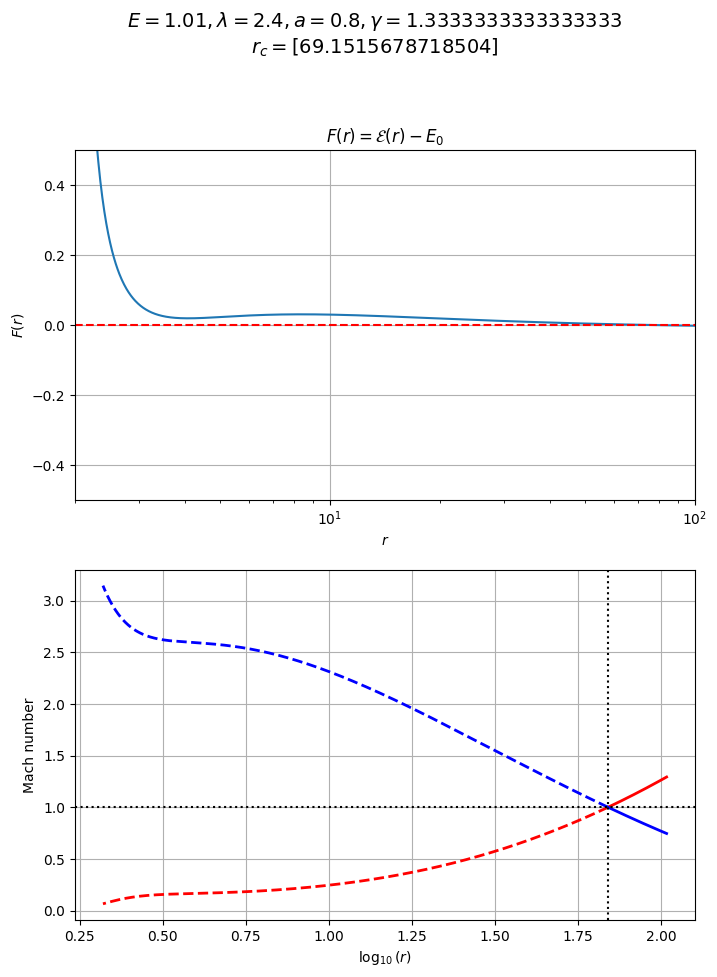

In [4]:
sonic_solution_pipeline(1.01 , 2.4 , 0.8 , 4/3)

# I-type solution(only inner sonic point exists)

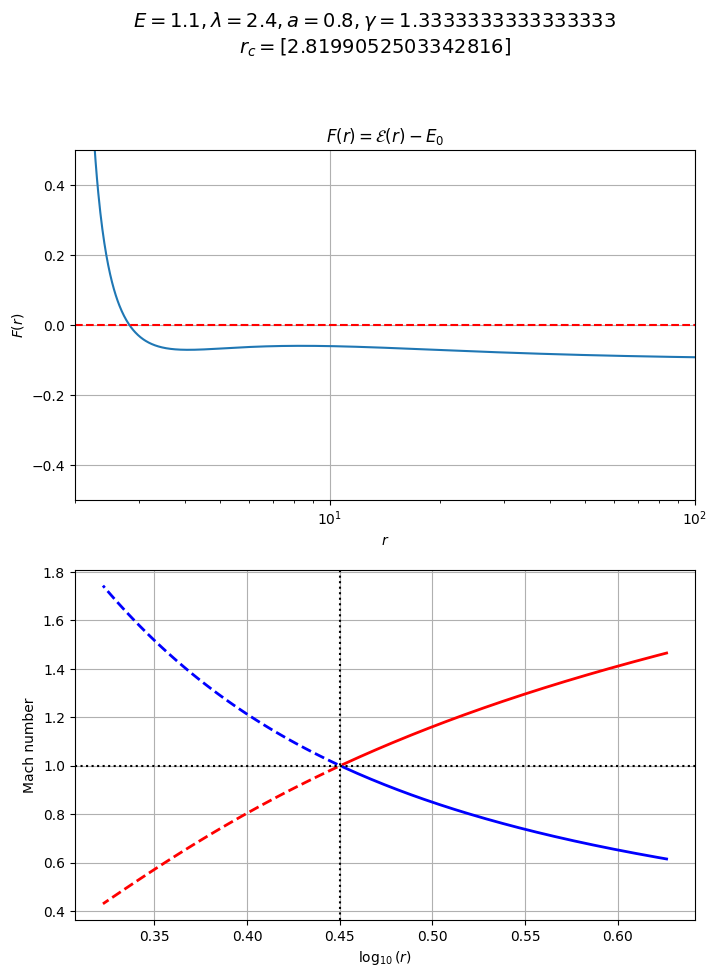

In [9]:
sonic_solution_pipeline(1.1 , 2.4 , 0.8 , 4/3)

# W-Type solution (both inner and outer sonic point are physical, global solution passes through inner and alpha-solution passes through outer)

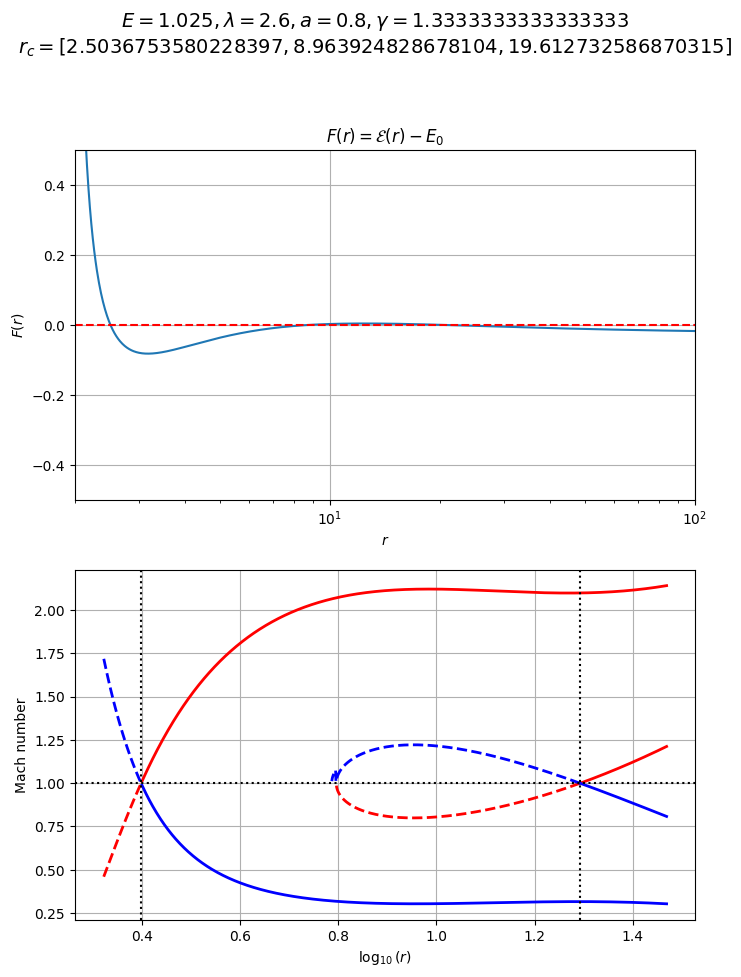

In [6]:
sonic_solution_pipeline(1.025 , 2.6 , 0.8 , 4/3)

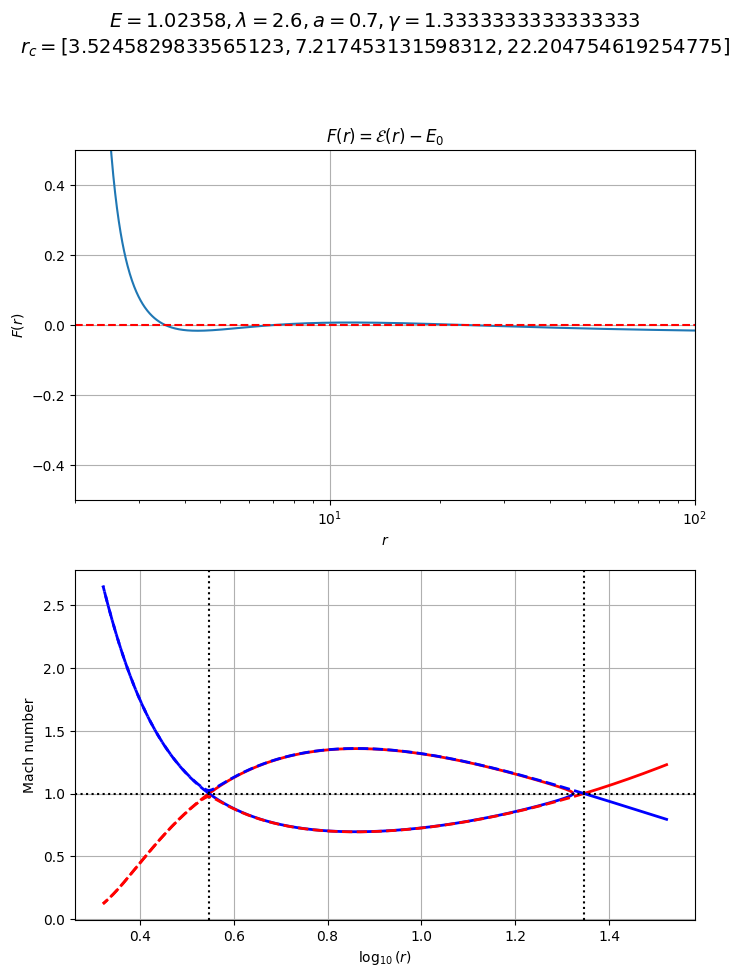

In [10]:
sonic_solution_pipeline(1.02358, 2.6 , 0.7 , 4/3)

# Type A (Both inner and outer sonic point exist and transonic solution passes though outer while alpha-solution passes though inner)

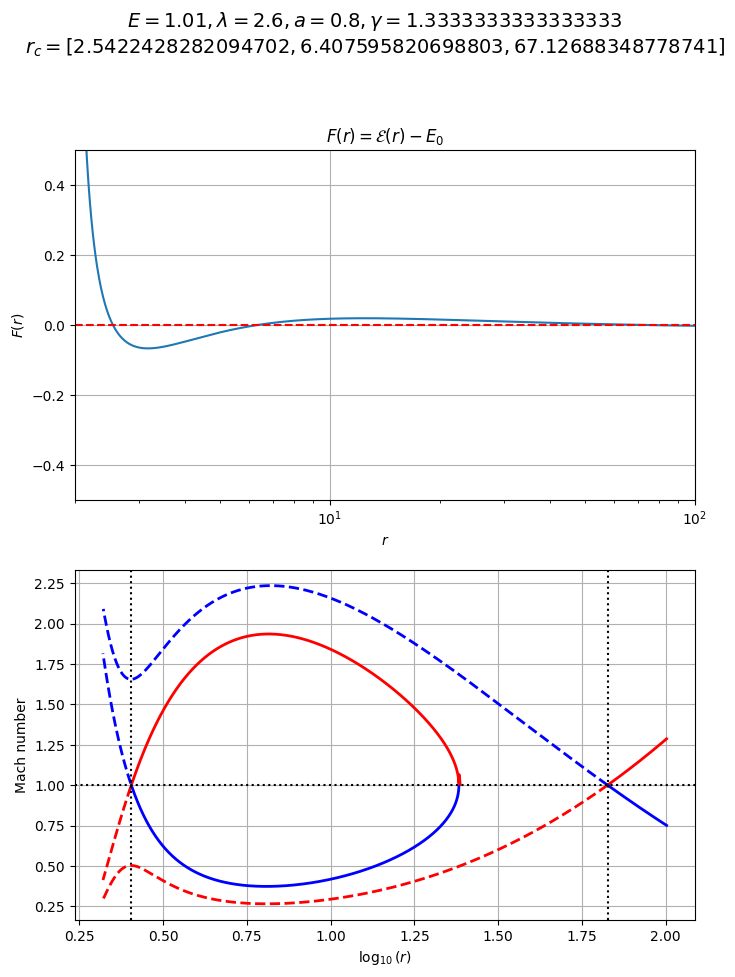

In [8]:
sonic_solution_pipeline(1.01 , 2.6 , 0.8 , 4/3)

# Different Types of solution in $\mathcal{{E}}$ - $\lambda$ - a (spin) parameter space

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import mplcursors
import csv
import os
import multiprocessing as mp

os.makedirs("alpha9.9", exist_ok=True)

# ------------------------------------------------------------------
# PLOT E vs rc
# ------------------------------------------------------------------
def plot_E_vs_rc(lambda_values, gamma, a, r_c_values):
    plt.figure(figsize=(10, 6))
    for lam in lambda_values:
        E_values = [Ec_computed_given_rc(r, lam, gamma, a) for r in r_c_values]
        plt.plot(r_c_values, E_values, label=f"$\lambda={lam:.4f}$")

    plt.xlabel(r"$r_c$ (Critical Radius)", fontsize=14)
    plt.ylabel(r"$\mathcal{E}$ (Specific Energy)", fontsize=14)
    plt.title(r"$\mathcal{E}$ vs $r_c$ for Different $\lambda$", fontsize=16)
    plt.legend(fontsize=12)
    plt.xlim(1.0, 20)
    plt.ylim(0.5, 1.2)
    plt.xticks(np.arange(2.0, 40, 2))
    plt.yticks(np.arange(1, 1.21, 0.05))
    plt.grid(alpha=0.5, linestyle='--', linewidth=0.5)
    plt.show()

# ------------------------------------------------------------------
# Newton-Raphson
# ------------------------------------------------------------------
def newton_root(F, x0, tol=1e-10, maxiter=80):
    x = x0
    for _ in range(maxiter):
        fx = F(x)
        if not np.isfinite(fx):
            return np.nan
        h = 1e-6 * max(1.0, abs(x))
        dfx = (F(x + h) - F(x - h)) / (2*h)
        if not np.isfinite(dfx) or dfx == 0:
            return np.nan
        x_new = x - fx/dfx
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return np.nan

# ------------------------------------------------------------------
# Mach branch checker
# ------------------------------------------------------------------
def same_mach_branch(M, M_ref):
    return (M - 1) * (M_ref - 1) > 0

# ==================================================================
# ===================== MAIN DRIVER FUNCTION ========================
# ==================================================================
def sonic_solution_pipeline_prime(E0, lam0, a0, gamma0, guesses):
    def F_num(r):
        return Ec_computed_given_rc(r, lam0, gamma0, a0) - E0

    roots = []
    for g in guesses:
        r0 = newton_root(F_num, g)
        if np.isfinite(r0):
            roots.append(r0)

    roots = sorted(set(np.round(roots, 6)))

    if len(roots) >= 3:
        roots = [roots[0], roots[-1]]

    cat = "A"
    fig, ax = plt.subplots(figsize=(7, 5))

    for idx, r0 in enumerate(roots, start=1):
        val = find_metric_quantities_and_gradient(r0, lam0, a0)
        u0 = find_u_sonic(r0, val)
        cs0 = u0
        r_inner = 1 + (1-a**2)**0.5
        slopes = find_vel_gradient_at_critical(u0, cs0, gamma0, lam0, a0, r0)

        for v0 in slopes:
            branch = "Wind" if v0 > 0 else "Accretion"
            color = "red" if branch == "Wind" else "blue"
            s0 = find_cs_gradient_at_critical(u0, v0, cs0, gamma0, lam0, a0, r0, val)

            # ---------------- OUTWARD ----------------
            R, u, cs = r0, u0, cs0
            h = 1e-2
            R += h
            u += h * v0
            cs += h * s0
            M_ref = u / cs
            Rout, Uout, CSout = [R], [u], [cs]

            while r_inner < R < roots[-1] * 1.5:
                u_n, cs_n = rk4_step(R, u, cs, h, gamma0, lam0, a0)
                R_n = R + h
                if not (0 < u_n < 1 and 0 < cs_n < 1):
                    break
                if not same_mach_branch(u_n / cs_n, M_ref):
                    cat = "A"
                    break
                Rout.append(R_n)
                Uout.append(u_n)
                CSout.append(cs_n)
                R, u, cs = R_n, u_n, cs_n

            # ---------------- INWARD ----------------
            R, u, cs = r0, u0, cs0
            h = -1e-2
            R += h
            u += h * v0
            cs += h * s0
            M_ref = u / cs
            Rin, Uin, CSin = [R], [u], [cs]

            while r_inner < R < roots[-1] * 1.5:
                u_n, cs_n = rk4_step(R, u, cs, h, gamma0, lam0, a0)
                R_n = R + h
                if not (0 < u_n < 1 and 0 < cs_n < 1):
                    break
                if not same_mach_branch(u_n / cs_n, M_ref):
                    cat = "W"
                    break
                Rin.append(R_n)
                Uin.append(u_n)
                CSin.append(cs_n)
                R, u, cs = R_n, u_n, cs_n

            ax.plot(np.log10(Rout), np.array(Uout) / np.array(CSout), color=color, lw=2)
            ax.plot(np.log10(Rin), np.array(Uin) / np.array(CSin), color=color, lw=2, ls="--")

        ax.axvline(np.log10(r0), color="k", ls=":")

    ax.axhline(1, color="k", ls=":")
    ax.set_ylabel("Mach number")
    ax.set_xlabel(r"$\log_{10}(r)$")
    ax.grid()

    plt.savefig(f"alpha9.9/E{E0:.3f}_lam{lam0:.2f}_cat{cat}.png", dpi=200, bbox_inches="tight")
    plt.close()
    return cat

# ------------------------------------------------------------------
# Find extrema
# ------------------------------------------------------------------
def find_local_extrema(lam, r_c_values, gamma, a):
    max_lam = lam[-1]
    min_lam = lam[0]
    minima = float('inf')
    maxima = float('-inf')
    for r in r_c_values:
        if 2.0 <= r <= 20.0:
            minE = Ec_computed_given_rc(r, max_lam, gamma, a)
            minima = min(minima, minE)
        if 10.0 < r:
            maxE = Ec_computed_given_rc(r, min_lam, gamma, a)
            maxima = max(maxima, maxE)
    return minima, maxima

# ------------------------------------------------------------------
# Count sonic points
# ------------------------------------------------------------------
def count_sonic_points(E, lam, gamma, a, r_c_values):
    F = [Ec_computed_given_rc(r, lam, gamma, a) - E for r in r_c_values]
    sonic_points = 0
    guesses = []
    for i in range(len(F) - 1):
        if F[i] * F[i + 1] < 0:
            sonic_points += 1
            guesses.append(0.5 * (r_c_values[i] + r_c_values[i + 1]))
    return sonic_points, guesses

# ==================================================================
# ===================== PARALLEL WORKER =============================
# ==================================================================
def worker_for_lambda(lam):
    local_rows = []
    counter = False
    fill_I = False

    for E in E_values:
        num_sonic_points, guesses = count_sonic_points(E, lam, gamma, a, r_c_values)

        if num_sonic_points == 3:
            counter = True
            category = sonic_solution_pipeline_prime(E, lam, a, gamma, guesses)
            print(f"[λ={lam:.2f}]  E={E:.5f}  N={num_sonic_points} -> {category}")

        elif num_sonic_points == 1:
            if fill_I:
                category = "I"
            else:
                if counter == False and guesses[0] > r_crit:
                    category = "O"
                elif counter == True and guesses[0] > r_crit:
                    category = "I"
                else:
                    category = "I"
            print(f"[λ={lam:.2f}]  E={E:.4f}  N={num_sonic_points} -> {category}")
        else:
            category = "X"

        local_rows.append({
            "Lambda": lam,
            "E": E,
            "Sonic Points": num_sonic_points,
            "Category": category
        })

    return local_rows

# ==================================================================
# ========================= MAIN ===================================
# ==================================================================
gamma = 4.0 / 3.0
a = 0.99
lambda_values = np.arange(1.8, 2.2, 0.05)
r_inner = 1 + (1-a**2)**0.5
r_c_values = np.linspace(r_inner, 200.0, 200000)

plot_E_vs_rc(lambda_values, gamma, a, r_c_values)

maxE = float(input("Enter the maximum value of E: "))
E_values = np.linspace(1.0, maxE, 200)
r_crit = float(input("Enter r_c: "))


if __name__ == "__main__":

    with mp.Pool(processes=len(lambda_values)) as pool:
        results = pool.map(worker_for_lambda, lambda_values)

    global_data = [row for sublist in results for row in sublist]

    csv_filename = "alpha9.9.csv"
    with open(csv_filename, "w", newline="") as csvfile:
        fieldnames = ["Lambda", "E", "Sonic Points", "Category"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(global_data)

    print(f"\nParallel run finished. Data saved to {csv_filename}")


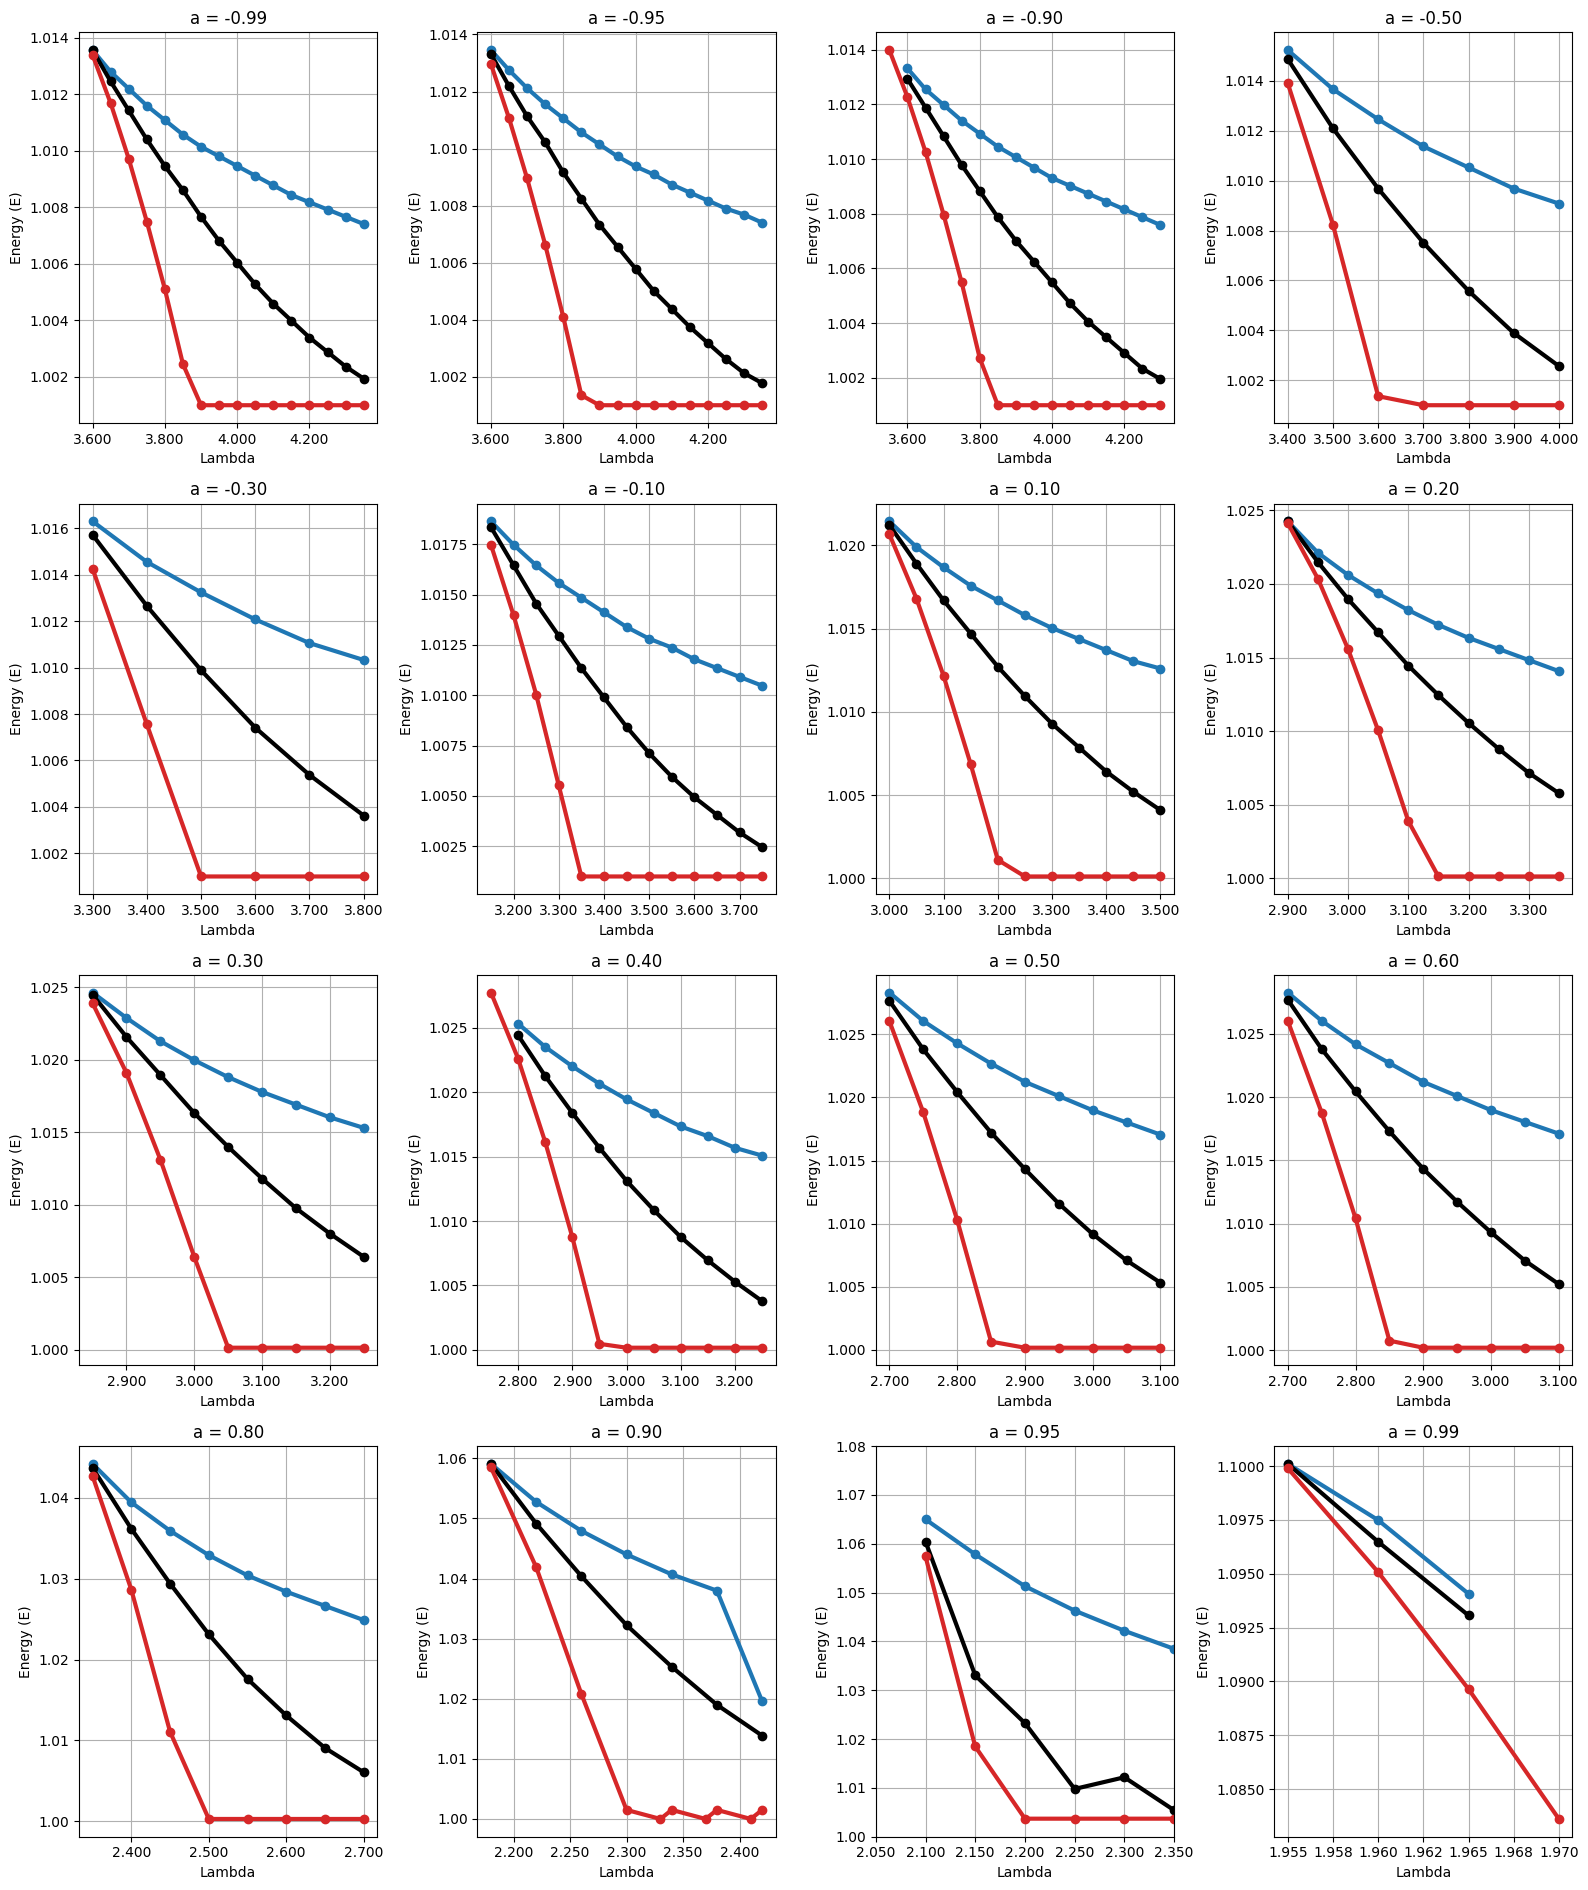

In [67]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

csv_files = ['alpha-9.9.csv', 'alpha-9.5.csv', 'alpha-9.csv', 'alpha-5.csv', 'alpha-3.csv', 'alpha-1.csv', 'alpha1.csv', 'alpha2.csv', 'alpha3.csv', 'alpha4.csv', 'alpha5.csv', 'alpha6.csv', 'alpha8.csv', 'alpha9.0.csv', 'alpha9.5.csv', 'alpha9.9.csv']

colors = {
    'A': 'tab:red',
    'W': 'tab:blue',
    'I': 'tab:green',
    'O': 'tab:purple'
}

# Calculate the number of rows and columns for subplots
plots_per_row = 4
num_rows = (len(csv_files) + plots_per_row - 1) // plots_per_row  # Ceiling division

fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(16, 5 * num_rows))

# Flatten axes array for easier indexing
axes = axes.flatten()

def sort_pair(lam, e):
    lam = np.array(lam)
    e = np.array(e)
    idx = np.argsort(lam)
    return lam[idx], e[idx]

# Formatter for x-axis to show only 2 decimal places
formatter = FuncFormatter(lambda x, _: f'{x:.3f}')

for i, csv_file in enumerate(csv_files):
    ax = axes[i]

    # Extract `a` from the file name
    a = 0.1 * float(csv_file.replace("alpha", "").replace(".csv", ""))
    data = pd.read_csv(csv_file)

    Lambda = data["Lambda"].values
    Energy = data["E"].values
    Category = data["Category"].values

    ax.set_title(f"a = {a:.2f}")
    ax.set_xlabel("Lambda")
    ax.set_ylabel("Energy (E)")
    ax.grid(True)

    # Apply the formatter to the x-axis
    ax.xaxis.set_major_formatter(formatter)

    lam_W_max, E_W_max = [], []
    lam_W_min, E_W_min = [], []
    lam_A_min, E_A_min = [], []

    # ---------- BLUE W UPPER + LOWER ----------
    dfW = data[data["Category"] == "W"]
    if len(dfW) > 0:
        grouped_max = dfW.groupby("Lambda")["E"].max().reset_index()
        grouped_min = dfW.groupby("Lambda")["E"].min().reset_index()

        lam_W_max, E_W_max = sort_pair(grouped_max["Lambda"], grouped_max["E"])
        lam_W_min, E_W_min = sort_pair(grouped_min["Lambda"], grouped_min["E"])

        ax.plot(lam_W_max, E_W_max,
                color="tab:blue", linewidth=3, marker="o",
                label=None)

        ax.plot(lam_W_min, E_W_min,
                color="black", linewidth=3, marker="o",
                label=None)

    # ---------- RED A LOWER ----------
    dfA = data[data["Category"] == "A"]
    if len(dfA) > 0:
        grouped_Amin = dfA.groupby("Lambda")["E"].min().reset_index()
        lam_A_min, E_A_min = sort_pair(grouped_Amin["Lambda"], grouped_Amin["E"])

        ax.plot(lam_A_min, E_A_min,
                color="tab:red", linewidth=3, marker="o",
                label=None)

    # Set specific xlim and ylim for a = 0.95
    if np.isclose(a, 0.95, atol=1e-2):  # Check if a is approximately 0.95
        ax.set_xlim(2.05, 2.35)
        ax.set_ylim(1.0, 1.08)

# Hide unused subplots
for j in range(len(csv_files), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make space for the legend
plt.show()

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Save folder
# ============================================================
OUTDIR = "variation"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------------
# PLOT (single) E vs rc on a given axis
# ------------------------------------------------------------------
def plot_E_vs_rc_single(ax, lam, gamma, a, r_c_values, energies3, ylim=None):
    E_values = [Ec_computed_given_rc(r, lam, gamma, a) for r in r_c_values]
    ax.plot(r_c_values, E_values, lw=2, label="E vs rc")
    
    # Mark energies as horizontal lines
    for energy in energies3:
        ax.axhline(energy, color="orange", linestyle="--", linewidth=1, label=rf"$E={energy:.4f}$")
    
    ax.set_title(rf"$\lambda={lam:.4f}$")
    ax.set_xlabel(r"$r_c$")
    ax.set_ylabel(r"$\mathcal{{E}}$")
    ax.set_xscale('log')
    ax.set_xlim(1.5, 100)
    
    # Set ylim if provided
    if ylim:
        ax.set_ylim(ylim)
    else:
        ax.set_ylim(0.7, 1.12)
    
    ax.grid(alpha=0.5, linestyle="--", linewidth=0.5)
    ax.legend()

# ------------------------------------------------------------------
# Newton-Raphson
# ------------------------------------------------------------------
def newton_root(F, x0, tol=1e-12, maxiter=200):
    x = x0
    for _ in range(maxiter):
        fx = F(x)
        if not np.isfinite(fx):
            return np.nan
        h = 1e-6 * max(1.0, abs(x))
        dfx = (F(x + h) - F(x - h)) / (2 * h)
        if (not np.isfinite(dfx)) or dfx == 0:
            return np.nan
        x_new = x - fx / dfx
        if abs(x_new - x) < tol:
            return x_new
        x = x_new
    return np.nan

# ------------------------------------------------------------------
# Mach branch checker
# ------------------------------------------------------------------
def same_mach_branch(M, M_ref):
    return (M - 1) * (M_ref - 1) > 0

# ------------------------------------------------------------------
# Count sonic points
# ------------------------------------------------------------------
def count_sonic_points(E, lam, gamma, a, r_c_values):
    F = [Ec_computed_given_rc(r, lam, gamma, a) - E for r in r_c_values]
    sonic_points = 0
    guesses = []
    for i in range(len(F) - 1):
        if F[i] * F[i + 1] < 0:
            sonic_points += 1
            guesses.append(0.5 * (r_c_values[i] + r_c_values[i + 1]))
    return sonic_points, guesses

# ==================================================================
# Plot sonic solution on a provided axis (NO saving/closing inside)
# ==================================================================
def sonic_solution_plot_on_ax(ax, E0, lam0, a0, gamma0, guesses):
    def F_num(r):
        return Ec_computed_given_rc(r, lam0, gamma0, a0) - E0

    roots = []
    for g in guesses:
        r0 = newton_root(F_num, g)
        if np.isfinite(r0):
            roots.append(r0)

    roots = sorted(set(np.round(roots, 6)))

    if len(roots) == 0:
        ax.text(0.5, 0.5, "No root found", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(rf"$E={E0:.4f},\ \lambda={lam0:.3f}$")
        ax.grid(True, alpha=0.3)
        return "X"

    if len(roots) >= 3:
        roots = [roots[0], roots[-1]]

    print(roots)
    cat = "S"

    for r0 in roots:
        val = find_metric_quantities_and_gradient(r0, lam0, a0)
        u0 = find_u_sonic(r0, val)
        cs0 = u0

        slopes = find_vel_gradient_at_critical(u0, cs0, gamma0, lam0, a0, r0)

        for v0 in slopes:
            branch = "Wind" if v0 >= 0 else "Accretion"
            color = "red" if branch == "Wind" else "blue"
            s0 = find_cs_gradient_at_critical(u0, v0, cs0, gamma0, lam0, a0, r0, val)

            # ---------------- OUTWARD ----------------
            R, u, cs = r0, u0, cs0
            h = 1e-2
            R += h
            u += h * v0
            cs += h * s0
            M_ref = u / cs
            Rout, Uout, CSout = [R], [u], [cs]

            Rmax = roots[-1] * 1.5
            while 2.0 < R < Rmax:
                u_n, cs_n = rk4_step(R, u, cs, h, gamma0, lam0, a0)
                R_n = R + h

                if not (0 < u_n < 1 and 0 < cs_n < 1):
                    break
                if not same_mach_branch(u_n / cs_n, M_ref):
                    cat = "A"
                    break

                Rout.append(R_n)
                Uout.append(u_n)
                CSout.append(cs_n)
                R, u, cs = R_n, u_n, cs_n

            # ---------------- INWARD ----------------
            R, u, cs = r0, u0, cs0
            h = -1e-2
            R += h
            u += h * v0
            cs += h * s0
            M_ref = u / cs
            Rin, Uin, CSin = [R], [u], [cs]

            while 2.0 < R < Rmax:
                u_n, cs_n = rk4_step(R, u, cs, h, gamma0, lam0, a0)
                R_n = R + h

                if not (0 < u_n < 1 and 0 < cs_n < 1):
                    break
                if not same_mach_branch(u_n / cs_n, M_ref):
                    cat = "W"
                    break

                Rin.append(R_n)
                Uin.append(u_n)
                CSin.append(cs_n)
                R, u, cs = R_n, u_n, cs_n

            ax.plot(np.log10(Rout), np.array(Uout) / np.array(CSout), color=color, lw=2)
            ax.plot(np.log10(Rin),  np.array(Uin)  / np.array(CSin),  color=color, lw=2, ls="--")

        # Dynamically calculate the maximum Mach number
        max_mach = max(max(np.array(Uout) / np.array(CSout)), max(np.array(Uin) / np.array(CSin)))

        ax.axvline(np.log10(r0), color="k", ls=":")

    ax.axhline(1, color="k", ls=":")
    ax.set_ylabel("Mach number")
    ax.set_xlabel(r"$\log_{10}(r)$")
    ax.grid(True, alpha=0.5)
    ax.set_title(rf"$E={E0:.4f},\ \lambda={lam0:.3f},\ cat={cat}$")
    return cat

# ==================================================================
# 6-panel plot + SAVE
# ==================================================================
def plot_six_subplots(energies3, lambdas3, gamma, a, r_c_values, outdir=OUTDIR, tag=None, ylim=None):
    energies3 = np.asarray(energies3, dtype=float)
    lambdas3  = np.asarray(lambdas3,  dtype=float)
    assert len(energies3) == 3 and len(lambdas3) == 3, "Need exactly 3 energies and 3 lambdas."

    fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

    # ---- top row: E vs rc ----
    for j, lam in enumerate(lambdas3):
        plot_E_vs_rc_single(axes[0, j], lam, gamma, a, r_c_values, energies3, ylim)

    # ---- bottom row: Mach plots for paired (E[i], lam[i]) ----
    cats = []
    for j, (E0, lam0) in enumerate(zip(energies3, lambdas3)):
        nsp, guesses = count_sonic_points(E0, lam0, gamma, a, r_c_values)
        ax = axes[1, j]
        if nsp != 3:
            ax.text(0.5, 0.5, rf"N sonic points = {nsp}", ha="center", va="center", transform=ax.transAxes)
            ax.set_title(rf"$E={E0:.6f},\ \lambda={lam0:.4f}$")
            ax.grid(True, alpha=0.3)
            cats.append(f"N{nsp}")
        else:
            cat = sonic_solution_plot_on_ax(ax, E0, lam0, a, gamma, guesses)
            cats.append(cat)

    # ---- build filename ----
    lam_show = float(lambdas3[0])
    tag = tag
    Etag = f"E[{energies3[0]:.8f},{energies3[1]:.8f},{energies3[2]:.8f}]"
    Ctag = f"cat[{cats[0]},{cats[1]},{cats[2]}]"
    fname = f"{tag}.png"

    # sanitize a bit for filesystem
    fname = fname.replace(" ", "").replace("/", "_").replace("\\", "_").replace(":", "_")

    path = os.path.join(outdir, fname)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {path}")
    return path

# ========================= RUN YOUR CASES =========================
gamma = 4.0 / 3.0

'''
# Case 1
a = -0.99
r_c_values = np.linspace(2.0, 100000.0, 1000000)
energies3 = [1.00002, 1.0019396984924622, 1.0074070351758793]
lambdas3  = [4.36, 4.36, 4.36]
plot_six_subplots(energies3, lambdas3, gamma, a, r_c_values, tag="case1", ylim=(0.99, 1.008))


# Case 2
a = -0.95
r_c_values = np.linspace(2.0, 10000.0, 1000000)
energies3 = [1.001, 1.0017035175879396, 1.0074020100502512]
lambdas3  = [4.35, 4.35, 4.35]
plot_six_subplots(energies3, lambdas3, gamma, a, r_c_values, tag="case2", ylim=(0.99, 1.01))


# Case 3
a = 0.1
r_c_values = np.linspace(2.0, 10000.0, 200000)
energies3 = [1.00012, 1.00399, 1.0126]
lambdas3  = [3.5, 3.5, 3.5]
plot_six_subplots(energies3, lambdas3, gamma, a, r_c_values, tag="case3", ylim=(0.95, 1.02))
'''
# Case 4
a = 0.95
r_c_values = np.linspace(2.0, 100.0, 200000)
energies3 = [1.0099989898989899, 1.0438383838383838, 1.0537373737373739]
lambdas3  = [2.16]*3
plot_six_subplots(energies3, lambdas3, gamma, a, r_c_values, tag="case4", ylim=(1.0, 1.08))


# Case 5
a = 0.99
r_c_values = np.linspace(2.0, 100.0, 200000)
energies3 = [1.0950953768844221, 1.096281407035176, 1.0974]
lambdas3  = [1.959999, 1.959999, 1.959999]
plot_six_subplots(energies3, lambdas3, gamma, a, r_c_values, tag="case5", ylim=(1.09, 1.1))



[2.35623, 2.522062]
[2.03517, 12.217974]
[2.001623, 8.10811]
Saved: variation/case4.png
[2.290018, 4.04123]
[2.169292, 3.789571]
[2.116497, 3.392981]
Saved: variation/case5.png


'variation/case5.png'

In [52]:
import os
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Save folder
# ============================================================
OUTDIR = "variation"
os.makedirs(OUTDIR, exist_ok=True)

# ------------------------------------------------------------------
# PLOT (single) E vs rc on a given axis
# ------------------------------------------------------------------
def plot_E_vs_rc(ax, lam, gamma, a, r_c_values, energies, ylim=None):
    E_values = [Ec_computed_given_rc(r, lam, gamma, a) for r in r_c_values]
    ax.plot(r_c_values, E_values, lw=2, label="E vs rc")
    
    # Mark energies as horizontal lines
    for energy in energies:
        ax.axhline(energy, color="orange", linestyle="--", linewidth=1, label=rf"$E={energy:.4f}$")
    
    inner_R = 1 + (1-a**2)**0.5
    # Mark vertical line at r = 2
    ax.axvline(inner_R, color="red", linestyle="--", linewidth=1, label=r"$r=2$")
    
    ax.set_title(rf"$\lambda={lam:.4f}$")
    ax.set_xlabel(r"$r_c$")
    ax.set_ylabel(r"$\mathcal{{E}}$")
    ax.set_xlim(0.9, 10)
    
    # Set ylim if provided

    ax.set_ylim(0.8, 1.2)
    
    ax.grid(alpha=0.5, linestyle="--", linewidth=0.5)
    ax.legend()
# ------------------------------------------------------------------
# Plot phase portrait for a given E
# ------------------------------------------------------------------
def plot_phase_portrait(ax, E, lam, gamma, a, r_c_values):
    
    print("E , lam = {", E,",", lam,"}")
    nsp, guesses = count_sonic_points(E, lam, gamma, a, r_c_values)
    if nsp == 0:
        ax.text(0.5, 0.5, "No sonic points", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(rf"$E={E:.4f}$")
        ax.grid(True, alpha=0.3)
        return

    def F_num(r):
        return Ec_computed_given_rc(r, lam, gamma, a) - E

    roots = []
    for g in guesses:
        r0 = newton_root(F_num, g)
        if np.isfinite(r0):
            roots.append(r0)

    roots = sorted(set(np.round(roots, 6)))

    if len(roots) == 0:
        ax.text(0.5, 0.5, "No root found", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(rf"$E={E:.4f}$")
        ax.grid(True, alpha=0.3)
        return

    print(roots)
    
    # Mark sonic points with vertical lines
    for r0 in roots:
        ax.axvline(r0, color="green", linestyle="--", linewidth=1, label=rf"$r_c={r0:.4f}$")

    
    if(len(roots)==3):
        roots = [roots[0],roots[-1]]
    
    for r0 in roots:
        val = find_metric_quantities_and_gradient(r0, lam, a)
        u0 = find_u_sonic(r0, val)
        cs0 = u0

        slopes = find_vel_gradient_at_critical(u0, cs0, gamma, lam, a, r0)

        print("dv/dr at r_c = ",slopes)
        
        for v0 in slopes:
            branch = "Wind" if v0 >= 0 else "Accretion"
            color = "red" if branch == "Wind" else "blue"
            s0 = find_cs_gradient_at_critical(u0, v0, cs0, gamma, lam, a, r0, val)
            
            inner_R = 1+(1-a**2)**0.5

            # ---------------- OUTWARD ----------------
            R, u, cs = r0, u0, cs0
            h = 1e-3
            R += h
            u += h * v0
            cs += h * s0
            M_ref = u / cs
            Rout, Uout, CSout = [R], [u], [cs]

            Rmax = 10.0
            while inner_R < R < Rmax:
                u_n, cs_n = rk4_step(R, u, cs, h, gamma, lam, a)
                R_n = R + h

                if not (0 < u_n < 1 and 0 < cs_n < 1):
                    break
                if not same_mach_branch(u_n / cs_n, M_ref):
                    break

                Rout.append(R_n)
                Uout.append(u_n)
                CSout.append(cs_n)
                R, u, cs = R_n, u_n, cs_n

            # ---------------- INWARD ----------------
            R, u, cs = r0, u0, cs0
            h = -1e-3
            R += h
            u += h * v0
            cs += h * s0
            M_ref = u / cs
            Rin, Uin, CSin = [R], [u], [cs]

            while inner_R < R < Rmax:
                u_n, cs_n = rk4_step(R, u, cs, h, gamma, lam, a)
                R_n = R + h

                if not (0 < u_n < 1 and 0 < cs_n < 1):
                    break
                if not same_mach_branch(u_n / cs_n, M_ref):
                    break

                Rin.append(R_n)
                Uin.append(u_n)
                CSin.append(cs_n)
                R, u, cs = R_n, u_n, cs_n

            # CHANGED: Plot r instead of log10(r)
            ax.plot(Rout, np.array(Uout) / np.array(CSout), color=color, lw=2)
            ax.plot(Rin,  np.array(Uin)  / np.array(CSin),  color=color, lw=2, ls="--")

    ax.axhline(1, color="k", ls=":")
    ax.set_ylabel("Mach number")
    ax.set_xlabel(r"$r$")  # CHANGED: from $\log_{10}(r)$ to $r$
    ax.grid(True, alpha=0.5)
    ax.set_title(rf"$E={E:.6f}$")
    
    # Optional: Set x-axis limits
    ax.set_xlim(inner_R, 10)

# ==================================================================
# Combined plot for E vs rc and phase portraits in a grid layout
# ==================================================================
def plot_combined_grid(lam, energies, gamma, a, r_c_values, outdir=OUTDIR, tag=None, ylim=None):
    energies = np.asarray(energies, dtype=float)
    n = len(energies)

    # Determine grid size (3 plots per row)
    ncols = 3
    nrows = (n + 1 + ncols - 1) // ncols  # +1 for the E vs rc plot

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), constrained_layout=True)
    axes = axes.flatten()

    # ---- E vs rc plot ----
    plot_E_vs_rc(axes[0], lam, gamma, a, r_c_values, energies, ylim)

    # ---- Phase portraits ----
    for i, E in enumerate(energies):
        plot_phase_portrait(axes[i + 1], E, lam, gamma, a, r_c_values)

    # Hide unused subplots
    for j in range(1 + n, len(axes)):
        axes[j].axis("off")

    # ---- Build filename ----
    tag = tag or f"lambda{lam:.4f}_a{a:+.3f}_gamma{gamma:.3f}"
    Etag = f"E[{','.join(f'{E:.6f}' for E in energies)}]"
    fname = f"{tag}_{Etag}.png"

    # Sanitize filename
    fname = fname.replace(" ", "").replace("/", "_").replace("\\", "_").replace(":", "_")

    path = os.path.join(outdir, fname)
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {path}")
    return path


# ========================= RUN YOUR CASE =========================
gamma = 4.0 / 3.0
a = 0.99
lam = 1.968
inner_R = 1 + (1-a**2)**0.5
r_c_values = np.linspace(inner_R, 7.0, 1000000)
E_values = [1.089421,1.0898, 1.09, 1.092, 1.0974, 1.0975]

plot_combined_grid(lam, E_values, gamma, a, r_c_values, tag="lam_zoom_in_1.968", ylim=(1.089, 1.09))

E , lam = { 1.089421 , 1.968 }
[2.00005, 2.637665, 4.648491]
dv/dr at r_c =  [0.017150107329477575, -0.1171952586594722]
dv/dr at r_c =  [0.0010291958571105383, -0.03079830580162587]
E , lam = { 1.0898 , 1.968 }
[1.991182, 2.675378, 4.5843]
dv/dr at r_c =  [0.019470593299300686, -0.1203039200057646]
dv/dr at r_c =  [0.0006750583937458595, -0.030994204918810803]
E , lam = { 1.09 , 1.968 }
[1.986751, 2.69579, 4.549786]
dv/dr at r_c =  [0.02065057906921579, -0.12188260368789247]
dv/dr at r_c =  [0.0004715224691729665, -0.0310939505665424]
E , lam = { 1.092 , 1.968 }
[1.949398, 2.937635, 4.164412]
dv/dr at r_c =  [0.031202044807285306, -0.13593053915391326]
dv/dr at r_c =  [-0.0026263042702872985, -0.03179028830274311]
E , lam = { 1.0974 , 1.968 }
[1.882069]
dv/dr at r_c =  [0.05358712635060484, -0.16529756499969325]
E , lam = { 1.0975 , 1.968 }
[1.881087]
dv/dr at r_c =  [0.05395213097028237, -0.16577155185152329]
Saved: variation/lam_zoom_in_1.968_E[1.089421,1.089800,1.090000,1.092000,1.

'variation/lam_zoom_in_1.968_E[1.089421,1.089800,1.090000,1.092000,1.097400,1.097500].png'

In [30]:
def find_E_for_r_equals_2(lam, gamma, a):
    r = 2.000000000  # Fixed value of r
    E = Ec_computed_given_rc(r, lam, gamma, a)
    if np.isfinite(E):
        print(f"For r = {r}, lambda = {lam}, gamma = {gamma}, a = {a}, E = {E:.10f}")
    else:
        print(f"For r = {r}, lambda = {lam}, gamma = {gamma}, a = {a}, E is undefined (NaN).")
    return E


# ========================= RUN YOUR CASE =========================
gamma = 4.0 / 3.0
a = 0.99
lam = 1.968

# Find E for r = 2
E_at_r_2 = find_E_for_r_equals_2(lam, gamma, a)

For r = 2.0, lambda = 1.968, gamma = 1.3333333333333333, a = 0.99, E = 1.0894230401


Lambda = 1.850000, Max ac = 0.950246323, Max ac^2 = 0.902968075
Lambda = 1.865556, Max ac = 0.948909544, Max ac^2 = 0.900429323
Lambda = 1.881111, Max ac = 0.947506402, Max ac^2 = 0.897768381
Lambda = 1.896667, Max ac = 0.946032584, Max ac^2 = 0.894977649
Lambda = 1.912222, Max ac = 0.944483570, Max ac^2 = 0.892049213
Lambda = 1.927778, Max ac = 0.942854681, Max ac^2 = 0.888974950
Lambda = 1.943333, Max ac = 0.941141166, Max ac^2 = 0.885746694
Lambda = 1.958889, Max ac = 0.939338335, Max ac^2 = 0.882356508
Lambda = 1.974444, Max ac = 0.937441788, Max ac^2 = 0.878797105
Lambda = 1.990000, Max ac = 0.935447752, Max ac^2 = 0.875062497


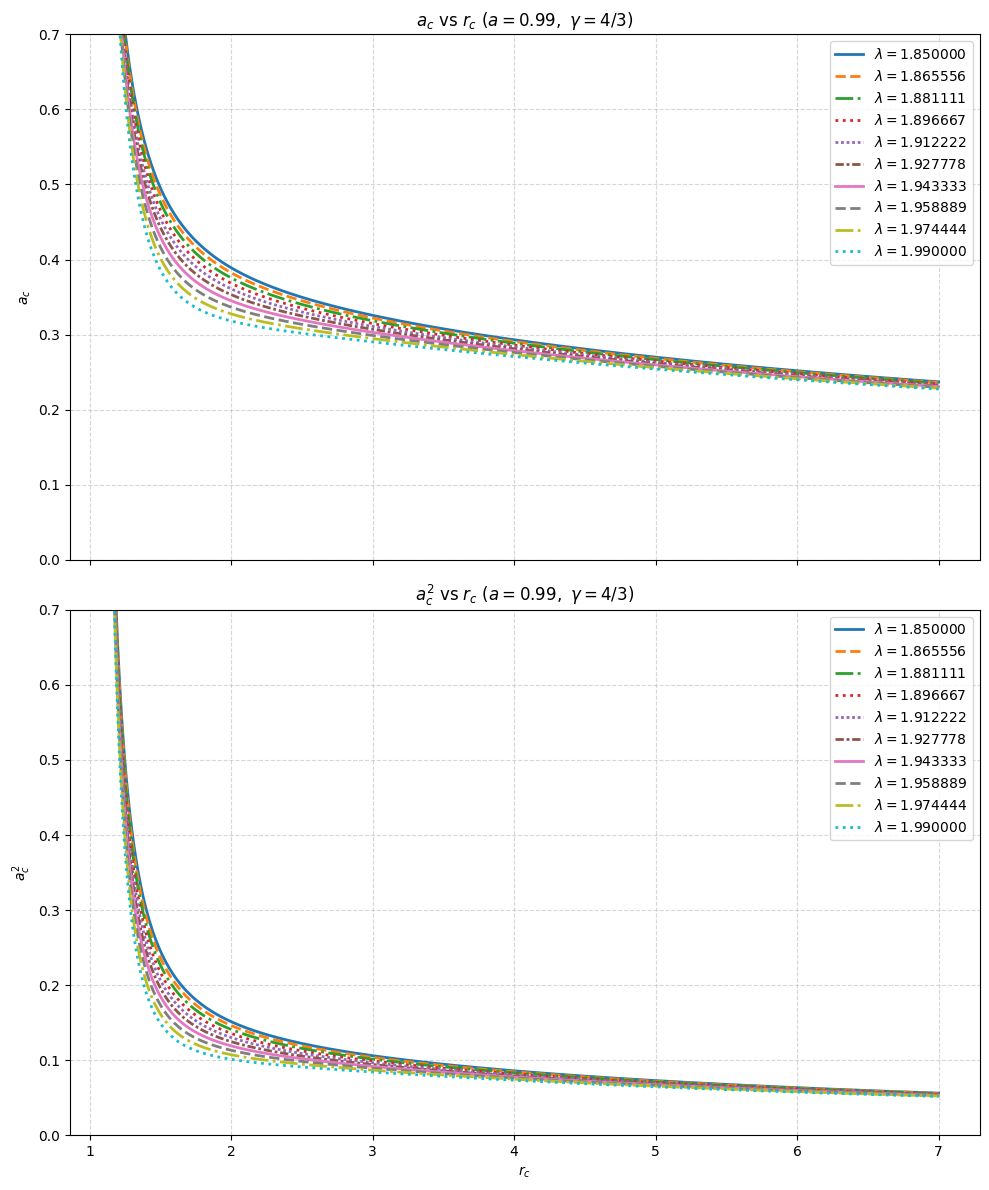

In [53]:
import numpy as np
import matplotlib.pyplot as plt

def ac_computed_given_rc(r, lam, gamma, a):
    Delta = r**2 - 2*r + a**2
    A     = r**4 + a**2*r**2 + 2*a**2*r
    if Delta <= 0 or A <= 0:
        return np.nan, np.nan

    Delta_prime = 2*r - 2
    A_prime     = 4*r**3 + 2*a**2*r + 2*a**2

    D = A**2 - 4*lam*a*r*A + lam**2 * r**2 * (4*a**2 - r**2 * Delta)
    if D == 0:
        return np.nan, np.nan

    D_prime = (
        2*A*A_prime
        - 4*lam*a*(A + r*A_prime)
        + lam**2 * (
            2*r*(4*a**2 - r**2*Delta)
            + r**2*(-2*r*Delta - r**2*Delta_prime)
        )
    )

    S1 = 0.5 * (Delta_prime/Delta + 2.0/r)
    S2 = 0.5 * (Delta_prime/Delta + A_prime/A + 2.0/r - D_prime/D)

    if S1 <= 0 or S2 <= 0:
        return np.nan, np.nan

    cs2 = S2 / S1
    if cs2 <= 0 or cs2 >= 1:
        return np.nan, np.nan

    return np.sqrt(cs2), cs2  # Return both ac and ac^2

def plot_ac_and_ac2_vs_rc():
    a = 0.99
    gamma = 4/3
    lambda_values = np.linspace(1.85, 1.99, 10)
    inner_R = 1 + (1-a**2)**0.5
    rc_values = np.linspace(inner_R, 7.0, 500)

    styles = ["-", "--", "-.", ":", (0, (1, 1)), (0, (3, 1, 1, 1))]  # no colors specified

    fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)  # Create two subplots

    for i, lam in enumerate(lambda_values):
        ac_vals = []
        ac2_vals = []
        for r in rc_values:
            ac, ac2 = ac_computed_given_rc(r, lam, gamma, a)
            ac_vals.append(ac)
            ac2_vals.append(ac2)

        ac_vals = np.array(ac_vals, dtype=float)
        ac2_vals = np.array(ac2_vals, dtype=float)

        print(f"Lambda = {lam:.6f}, Max ac = {np.nanmax(ac_vals):.9f}, Max ac^2 = {np.nanmax(ac2_vals):.9f}")
        
        # Plot ac vs rc
        axes[0].plot(rc_values, ac_vals, linestyle=styles[i % len(styles)], label=rf"$\lambda={lam:.6f}$", lw=2)
        
        # Plot ac^2 vs rc
        axes[1].plot(rc_values, ac2_vals, linestyle=styles[i % len(styles)], label=rf"$\lambda={lam:.6f}$", lw=2)

    # Customize the first plot (ac vs rc)
    axes[0].set_title(r"$a_c$ vs $r_c$ ($a=0.99,\ \gamma=4/3$)")
    axes[0].set_ylabel(r"$a_c$")
    axes[0].set_ylim(0, 0.7)  # Adjust y-limits for ac
    axes[0].grid(alpha=0.5, linestyle="--")
    axes[0].legend()

    # Customize the second plot (ac^2 vs rc)
    axes[1].set_title(r"$a_c^2$ vs $r_c$ ($a=0.99,\ \gamma=4/3$)")
    axes[1].set_xlabel(r"$r_c$")
    axes[1].set_ylabel(r"$a_c^2$")
    axes[1].set_ylim(0, 0.7)  # Adjust y-limits for ac^2
    axes[1].grid(alpha=0.5, linestyle="--")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_ac_and_ac2_vs_rc()